<a href="https://www.kaggle.com/code/lalit7881/idb-project-portfolio-1960-2025-eda-100?scriptVersionId=343212976" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/oscarpez/idb-project-portfolio-dataset-19602025/EN_IDB_Projects_List.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/oscarpez/idb-project-portfolio-dataset-19602025/EN_IDB_Projects_List.csv")

In [3]:
df.head()

,oper_num,oper_nm,apprvl_dt,sign_dt,cntry_cd,cntry_nm,publc_sts_nm,sector_cd,sector_nm,subsector_cd,...,modality_cd,modality_nm,facility_typ_cd,facility_typ_nm,envmntl_clssfctn_cd,envmntl_clssfctn_nm,lending_instrmnt_cd,lending_instrmnt_nm,lending_typ_cd,sts_cd
0,AR-G1002,Energy Efficiency and Renewable Energy in Low-...,2015-07-29T00:00,2017-03-15T00:00,AR,Argentina,Implementation,DU,URBAN DEVELOPMENT AND HOUSING,DU-VIV,...,NaN,NaN,NaN,NaN,C,Likely to cause minimal or no negative environ...,NaN,NaN,SG,ACTIVE
1,AR-G1003,Adaptation to Climate Change Consequences on t...,2014-02-03T00:00,2014-04-24T00:00,AR,Argentina,Closed,PA,ENVIRONMENT AND NATURAL DISASTERS,PA-ADA,...,NaN,NaN,NaN,NaN,C,Likely to cause minimal or no negative environ...,NaN,NaN,SG,EXITED
2,AR-G1004,Zolvers: A FinTech Platform for Domestic Workers,2018-09-26T00:00,2018-12-17T00:00,AR,Argentina,Closed,PS,PRIVATE FIRMS AND SME DEVELOPMENT,PS-MAJ,...,NaN,NaN,NaN,NaN,B13,Uncategorized Directive B.13,MIF,Multilateral Investment Fund Instrument,NSG,EXITED
3,AR-G1006,"Digitalization, New Sources Of Income And Resi...",2021-09-01T00:00,2021-11-19T00:00,AR,Argentina,Closed,PS,PRIVATE FIRMS AND SME DEVELOPMENT,PS-MIC,...,NaN,NaN,NaN,NaN,NaN,NaN,MIF,Multilateral Investment Fund Instrument,NSG,EXITED
4,AR-G1007,Córdoba GovTech: Developing the GovTech Ecosys...,2021-11-29T00:00,2022-05-03T00:00,AR,Argentina,Implementation,RM,REFORM / MODERNIZATION OF THE STATE,RM-EGO,...,NaN,NaN,NaN,NaN,C,Likely to cause minimal or no negative environ...,MIF,Multilateral Investment Fund Instrument,NSG,ACTIVE


In [4]:
df.tail()

,oper_num,oper_nm,apprvl_dt,sign_dt,cntry_cd,cntry_nm,publc_sts_nm,sector_cd,sector_nm,subsector_cd,...,modality_cd,modality_nm,facility_typ_cd,facility_typ_nm,envmntl_clssfctn_cd,envmntl_clssfctn_nm,lending_instrmnt_cd,lending_instrmnt_nm,lending_typ_cd,sts_cd
27324,VE0125,Agricultural Technology Program,2001-10-31T00:00,2002-03-11T00:00,VE,Venezuela,Closed,AG,AGRICULTURE AND RURAL DEVELOPMENT,AG,...,ESP,ESP (Specific Investment Operation),NaN,NaN,B(R),(R) Likely to cause mostly local and short-ter...,INV,Investment Loan,SG,EXITED
27325,VE0126,Rural Community Development Consolidation,2000-12-07T00:00,NaN,VE,Venezuela,Cancelled,AG,AGRICULTURE AND RURAL DEVELOPMENT,AG,...,INO,INO (Innovation Operation),NaN,NaN,NaN,NaN,INV,Investment Loan,SG,EXITED
27326,VE0138,Program for the Expansion and Improvement of I...,2005-11-30T00:00,2006-11-14T00:00,VE,Venezuela,Cancelled,ED,EDUCATION,ED-PRI,...,ESP,ESP (Specific Investment Operation),NaN,NaN,NaN,NaN,INV,Investment Loan,SG,EXITED
27327,VE0140,Minor Rural Population Aqueduct Attention,2002-12-18T00:00,2002-12-31T00:00,VE,Venezuela,Closed,AS,WATER AND SANITATION,AS,...,ESP,ESP (Specific Investment Operation),NaN,NaN,B(R),(R) Likely to cause mostly local and short-ter...,INV,Investment Loan,SG,EXITED
27328,VE0141,PEF:Support Operative Program Preparation,2002-12-11T00:00,NaN,VE,Venezuela,Implementation,OT,OTHER,OT,...,FAC,Facility,PROPEF,PROPEF (Facility for Project Preparation and E...,NaN,NaN,NaN,NaN,SG,ACTIVE


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27329 entries, 0 to 27328
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   oper_num               27329 non-null  object 
 1   oper_nm                27328 non-null  object 
 2   apprvl_dt              27015 non-null  object 
 3   sign_dt                22847 non-null  object 
 4   cntry_cd               27329 non-null  object 
 5   cntry_nm               27329 non-null  object 
 6   publc_sts_nm           27329 non-null  object 
 7   sector_cd              25294 non-null  object 
 8   sector_nm              25093 non-null  object 
 9   subsector_cd           27325 non-null  object 
 10  subsector_nm           25093 non-null  object 
 11  oper_typ_cd            27329 non-null  object 
 12  opertyp_nm             27329 non-null  object 
 13  objtv                  25684 non-null  object 
 14  orig_apprvd_useq_amnt  27329 non-null  float64
 15  to

In [6]:
df.describe()

,orig_apprvd_useq_amnt,totl_cost_orig,loc_cntrprt
count,2.732900e+04,2.728600e+04,2.589900e+04
mean,1.840797e+07,2.755034e+07,7.939353e+06
std,9.061413e+07,1.666248e+08,1.046679e+08
min,0.000000e+00,0.000000e+00,-2.540000e+08
25%,1.200000e+05,1.400000e+05,0.000000e+00
50%,3.500000e+05,4.295000e+05,0.000000e+00
75%,1.500000e+06,2.050000e+06,1.450000e+05
max,3.000000e+09,8.170000e+09,6.643000e+09


In [7]:
df.isnull().sum()

oper_num                     0
oper_nm                      1
apprvl_dt                  314
sign_dt                   4482
cntry_cd                     0
cntry_nm                     0
publc_sts_nm                 0
sector_cd                 2035
sector_nm                 2236
subsector_cd                 4
subsector_nm              2236
oper_typ_cd                  0
opertyp_nm                   0
objtv                     1645
orig_apprvd_useq_amnt        0
totl_cost_orig              43
loc_cntrprt               1430
lending_typ_nm               0
modality_cd              21467
modality_nm              21467
facility_typ_cd          27062
facility_typ_nm          27062
envmntl_clssfctn_cd      18407
envmntl_clssfctn_nm      18445
lending_instrmnt_cd      16749
lending_instrmnt_nm      16749
lending_typ_cd               0
sts_cd                       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

oper_num                  object
oper_nm                   object
apprvl_dt                 object
sign_dt                   object
cntry_cd                  object
cntry_nm                  object
publc_sts_nm              object
sector_cd                 object
sector_nm                 object
subsector_cd              object
subsector_nm              object
oper_typ_cd               object
opertyp_nm                object
objtv                     object
orig_apprvd_useq_amnt    float64
totl_cost_orig           float64
loc_cntrprt              float64
lending_typ_nm            object
modality_cd               object
modality_nm               object
facility_typ_cd           object
facility_typ_nm           object
envmntl_clssfctn_cd       object
envmntl_clssfctn_nm       object
lending_instrmnt_cd       object
lending_instrmnt_nm       object
lending_typ_cd            object
sts_cd                    object
dtype: object

In [10]:
df.shape

(27329, 28)

In [11]:
df.columns

Index(['oper_num', 'oper_nm', 'apprvl_dt', 'sign_dt', 'cntry_cd', 'cntry_nm',
       'publc_sts_nm', 'sector_cd', 'sector_nm', 'subsector_cd',
       'subsector_nm', 'oper_typ_cd', 'opertyp_nm', 'objtv',
       'orig_apprvd_useq_amnt', 'totl_cost_orig', 'loc_cntrprt',
       'lending_typ_nm', 'modality_cd', 'modality_nm', 'facility_typ_cd',
       'facility_typ_nm', 'envmntl_clssfctn_cd', 'envmntl_clssfctn_nm',
       'lending_instrmnt_cd', 'lending_instrmnt_nm', 'lending_typ_cd',
       'sts_cd'],
      dtype='object')

In [12]:
df.nunique()

oper_num                 27329
oper_nm                  24668
apprvl_dt                 8714
sign_dt                   8920
cntry_cd                    27
cntry_nm                    27
publc_sts_nm                 4
sector_cd                   19
sector_nm                   18
subsector_cd               167
subsector_nm               165
oper_typ_cd                  7
opertyp_nm                   7
objtv                    16167
orig_apprvd_useq_amnt     5323
totl_cost_orig            7626
loc_cntrprt               3999
lending_typ_nm               2
modality_cd                 35
modality_nm                 35
facility_typ_cd             11
facility_typ_nm             11
envmntl_clssfctn_cd         10
envmntl_clssfctn_nm          8
lending_instrmnt_cd          9
lending_instrmnt_nm         10
lending_typ_cd               2
sts_cd                       2
dtype: int64

## EDA

DATASET SHAPE
Rows    : 27329
Columns : 28

Columns:
['oper_num', 'oper_nm', 'apprvl_dt', 'sign_dt', 'cntry_cd', 'cntry_nm', 'publc_sts_nm', 'sector_cd', 'sector_nm', 'subsector_cd', 'subsector_nm', 'oper_typ_cd', 'opertyp_nm', 'objtv', 'orig_apprvd_useq_amnt', 'totl_cost_orig', 'loc_cntrprt', 'lending_typ_nm', 'modality_cd', 'modality_nm', 'facility_typ_cd', 'facility_typ_nm', 'envmntl_clssfctn_cd', 'envmntl_clssfctn_nm', 'lending_instrmnt_cd', 'lending_instrmnt_nm', 'lending_typ_cd', 'sts_cd']

Date columns converted successfully.


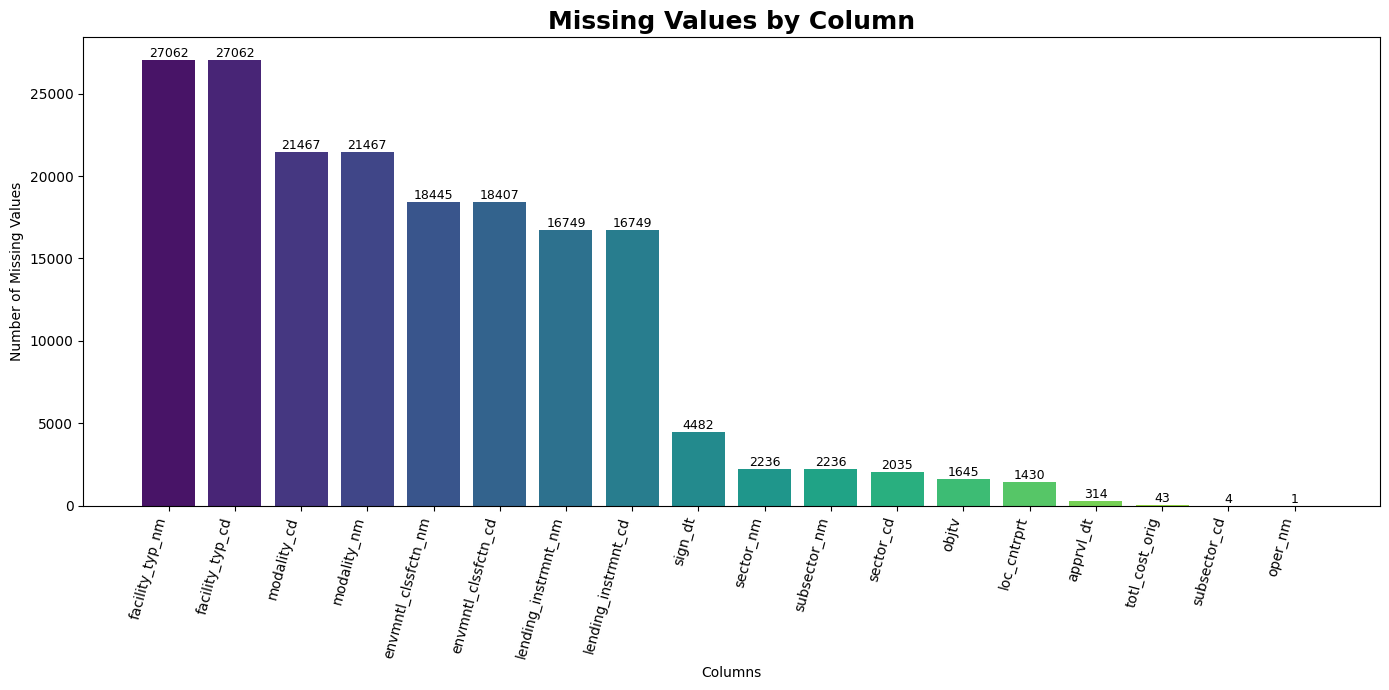

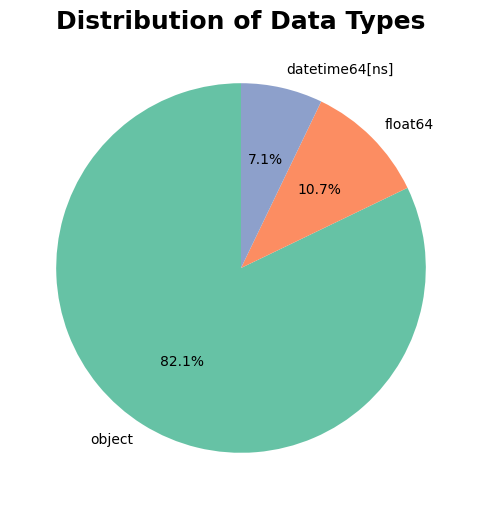

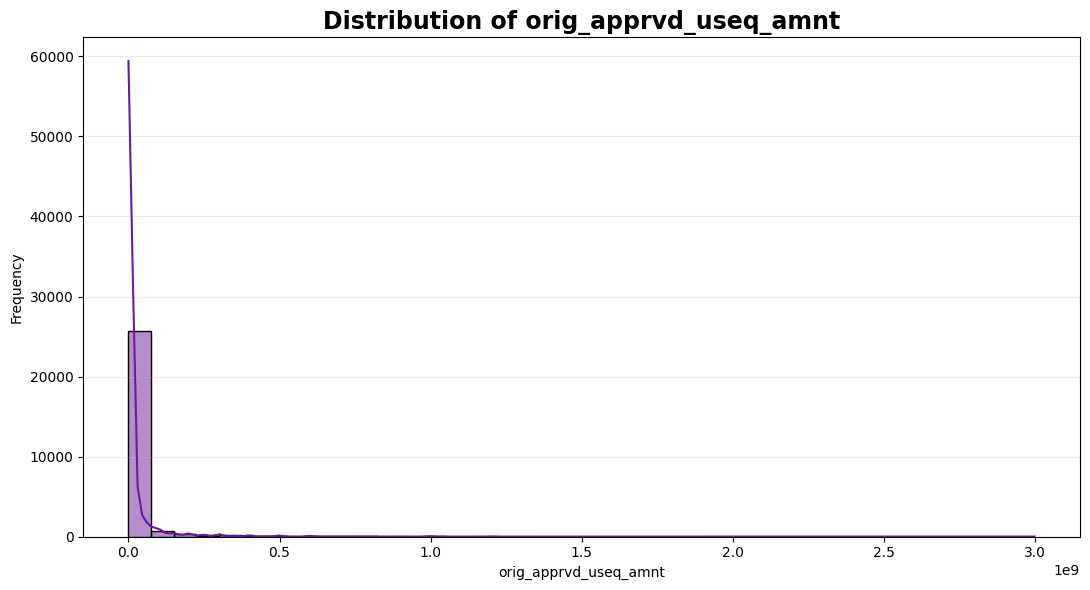

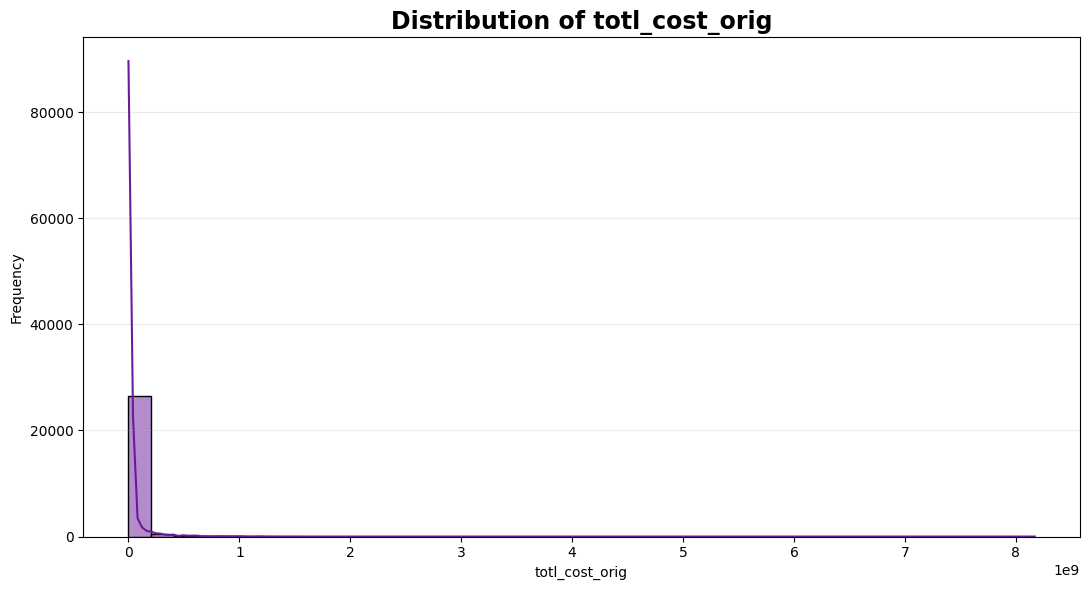

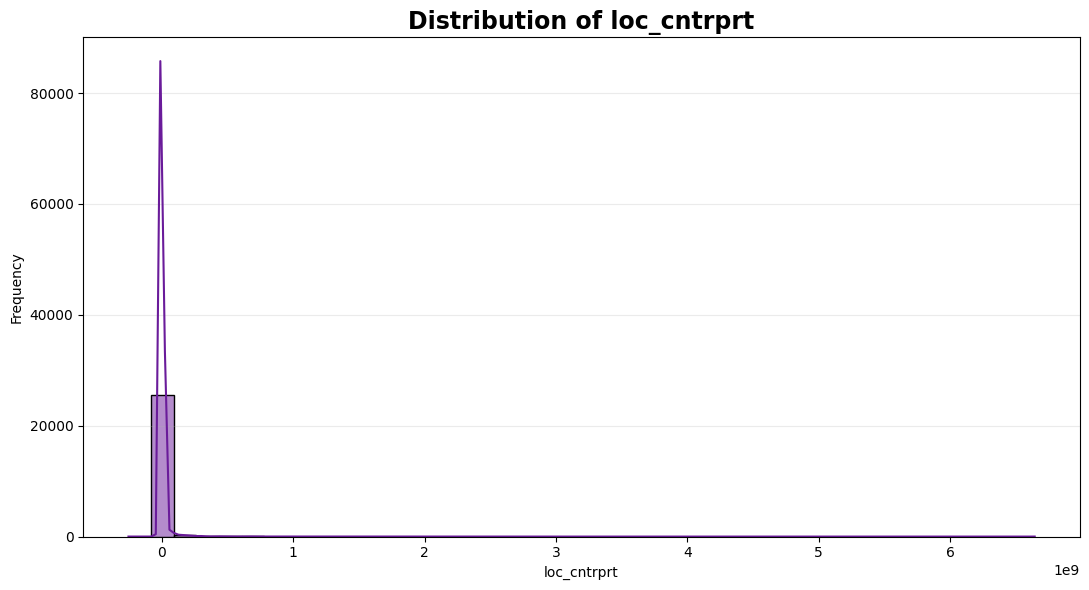

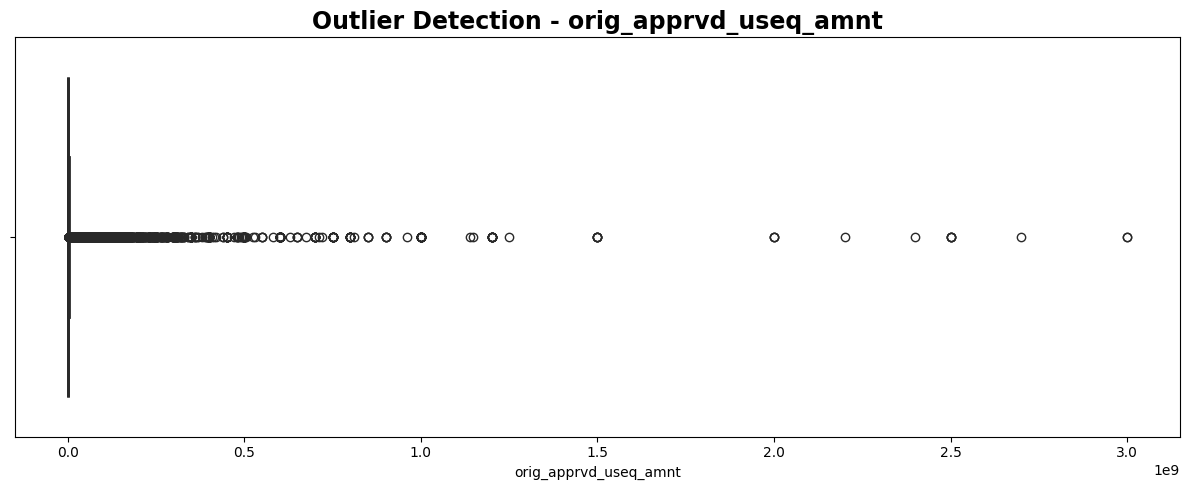

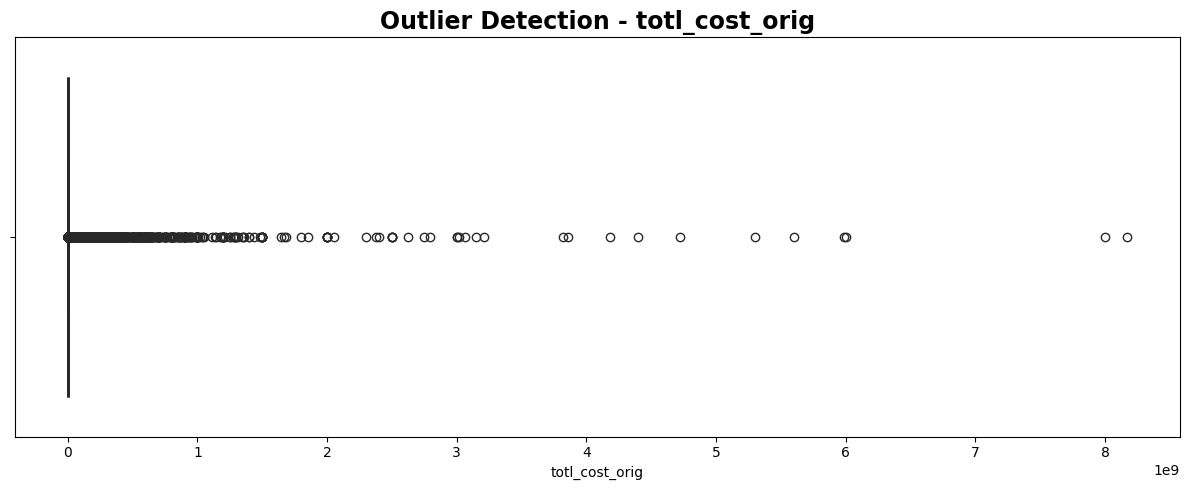

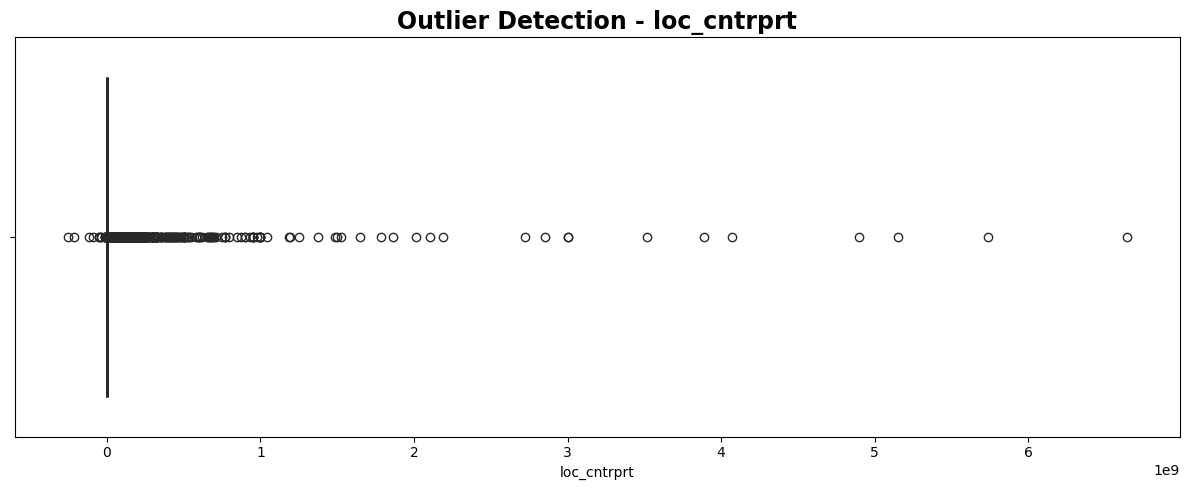

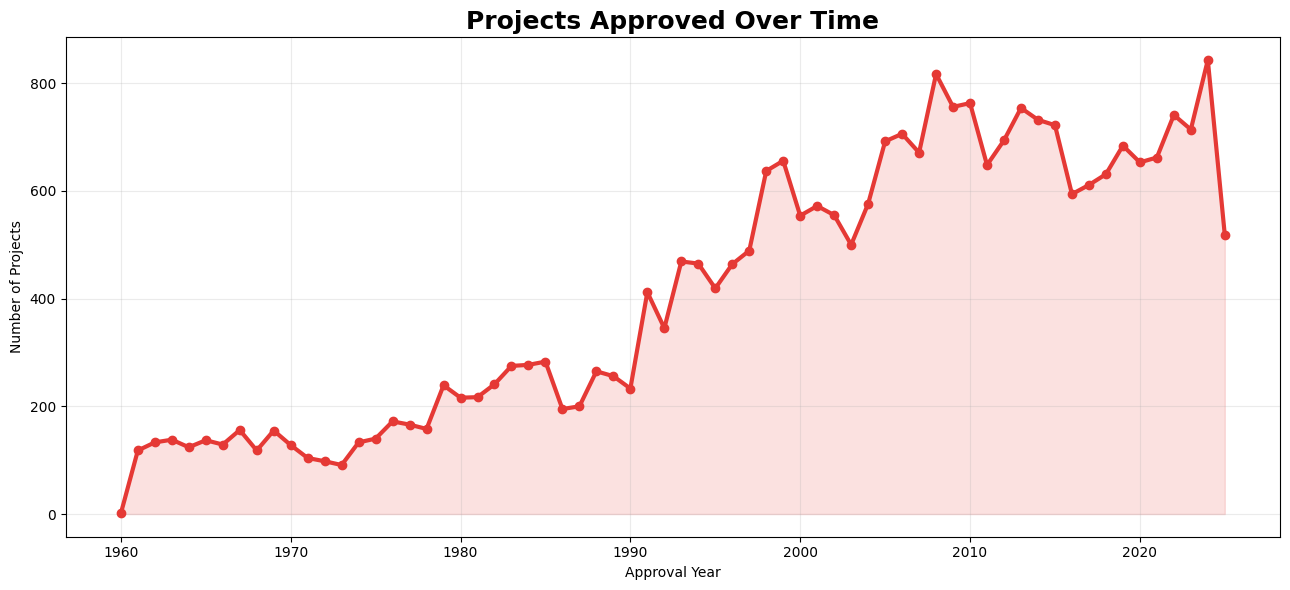

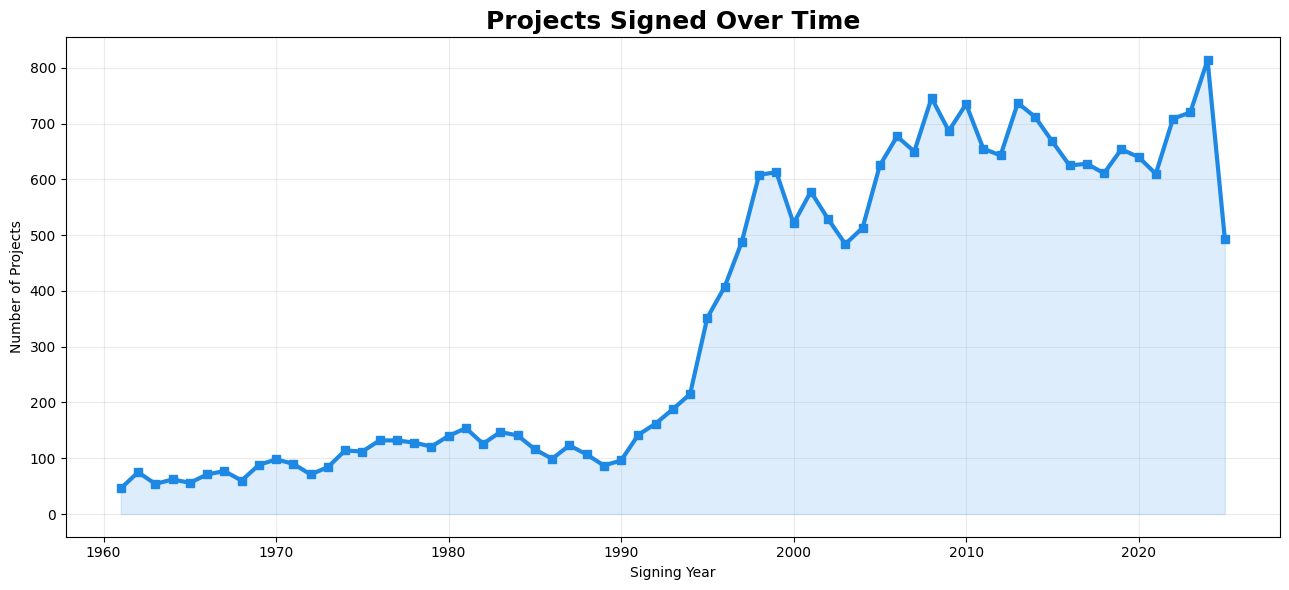

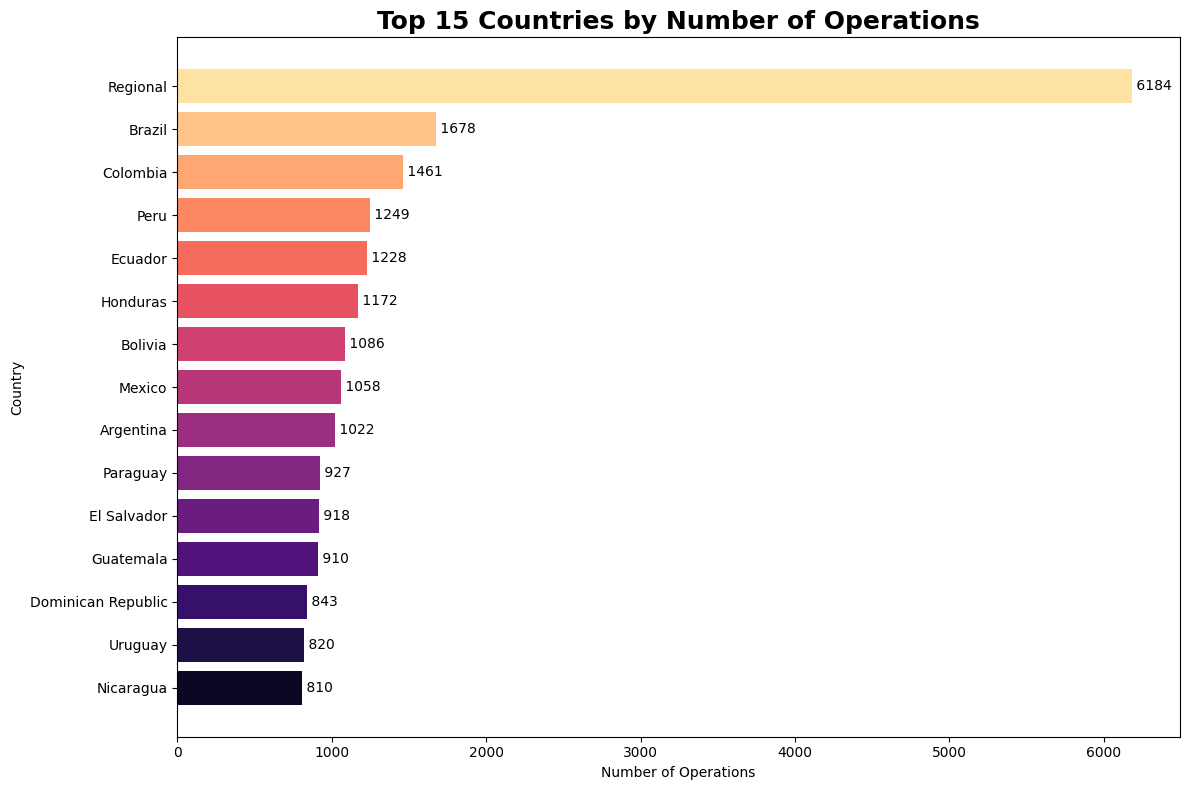

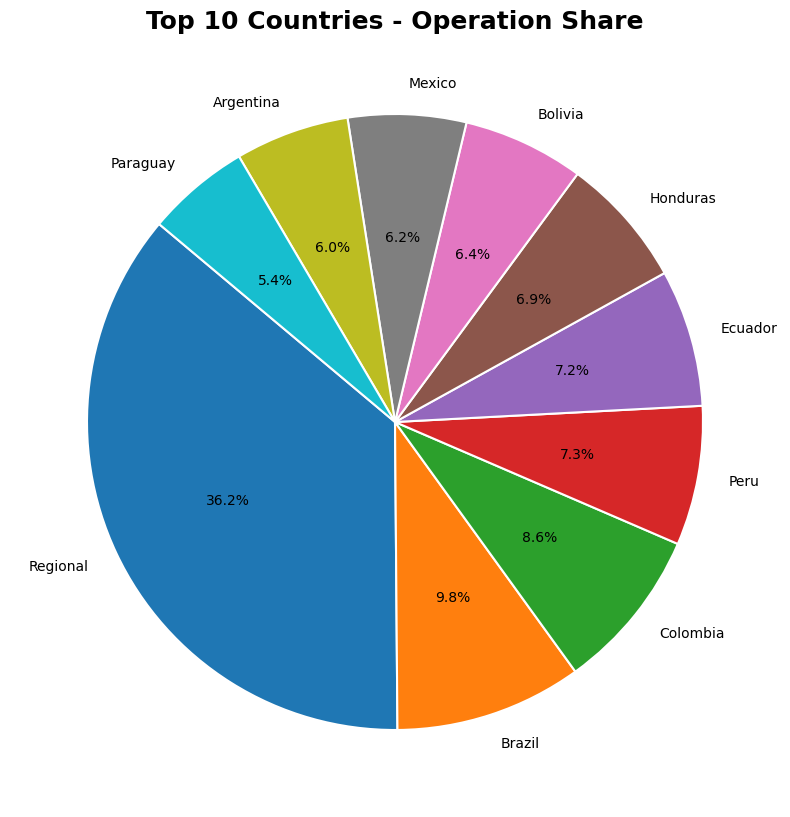

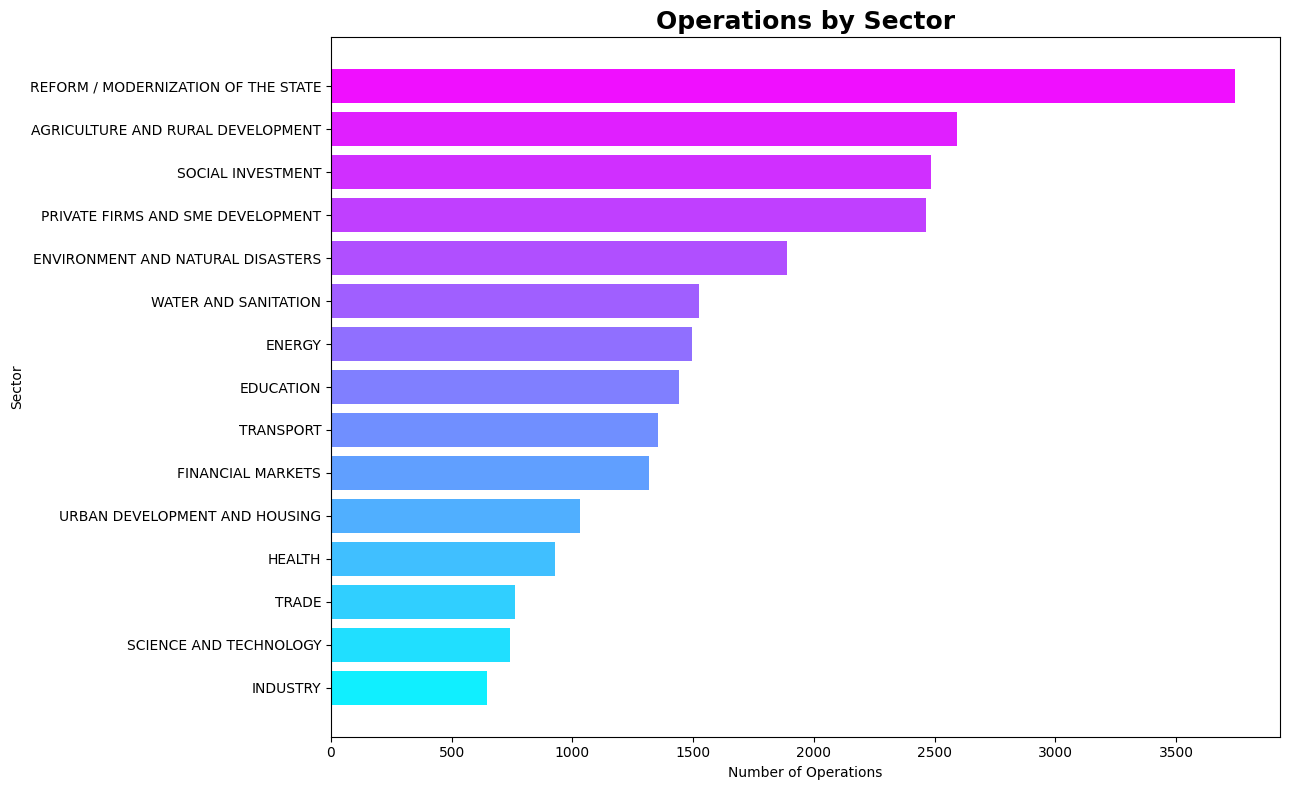

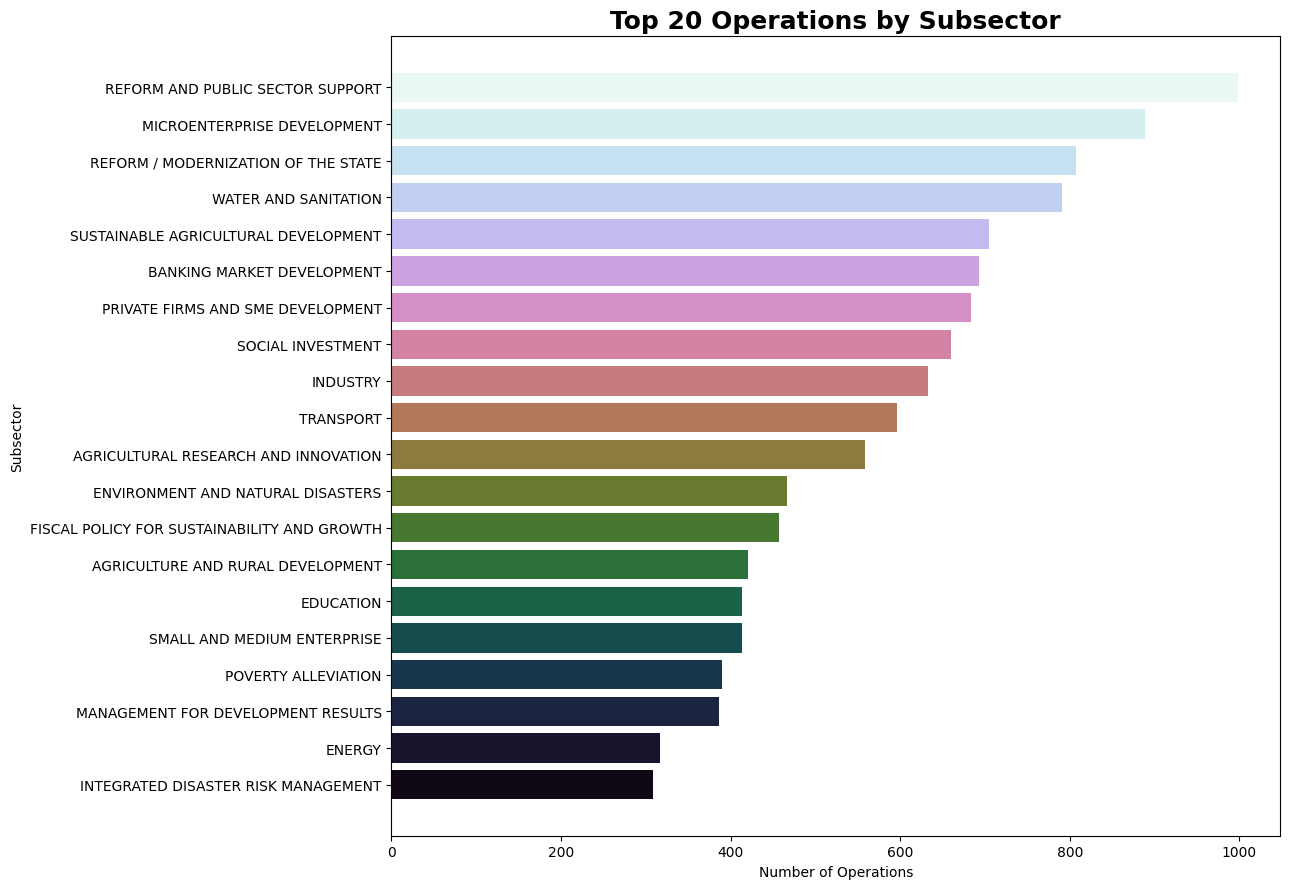

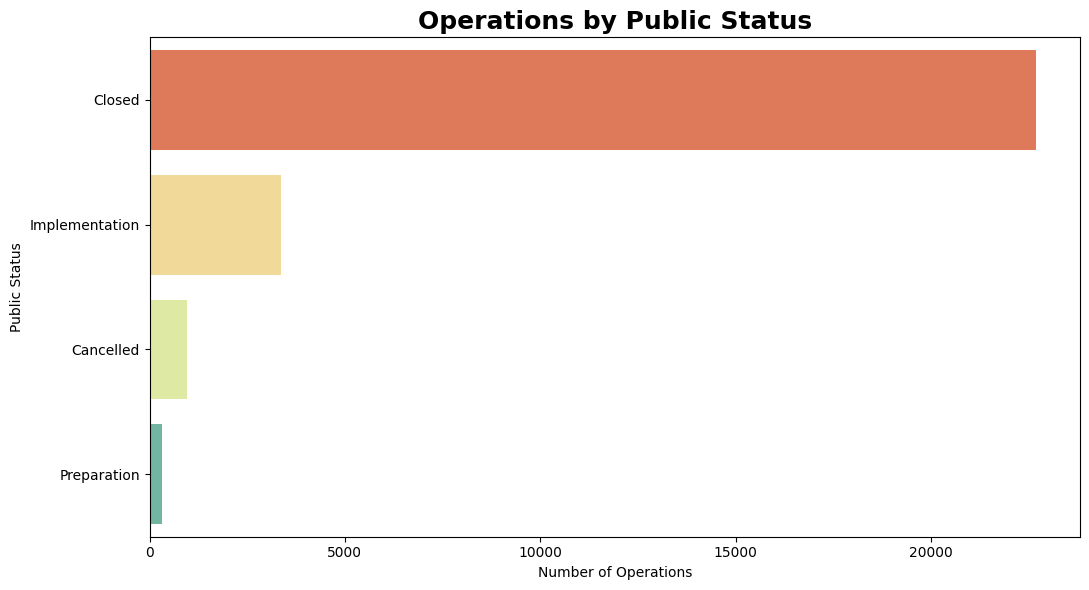

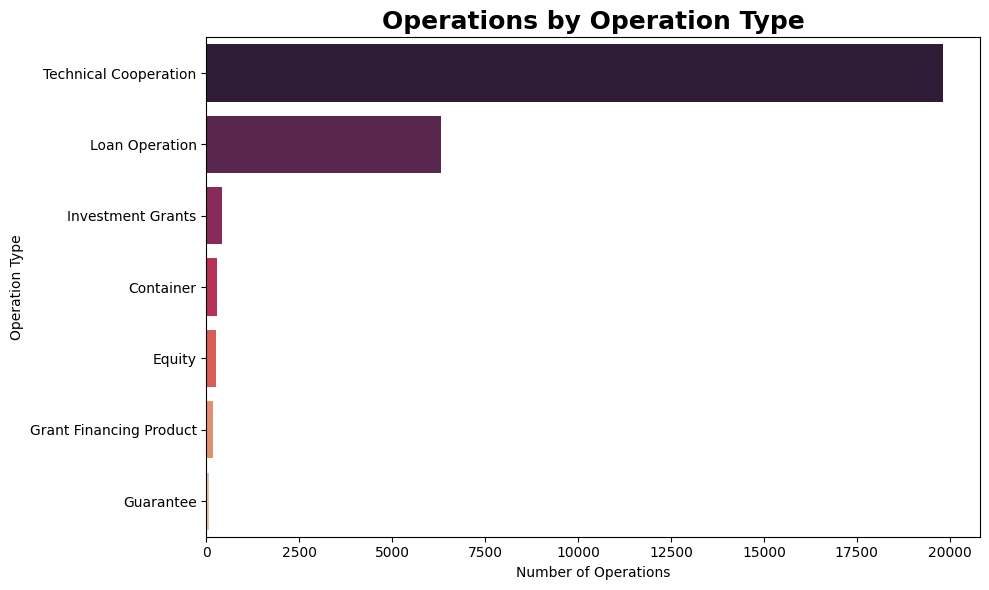

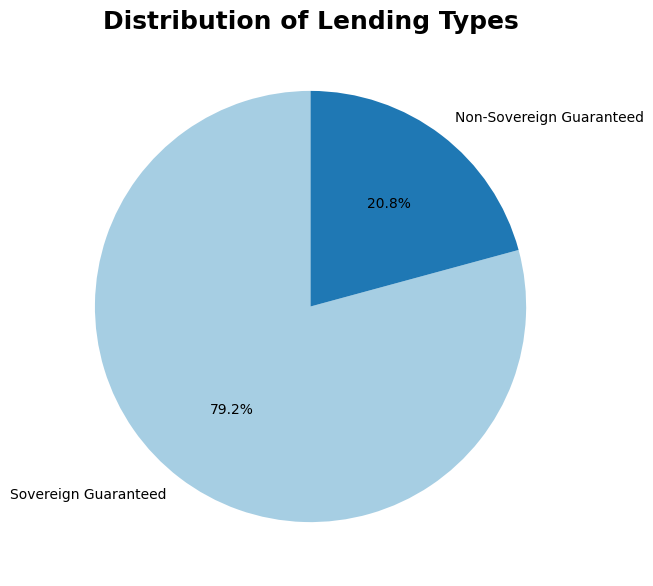

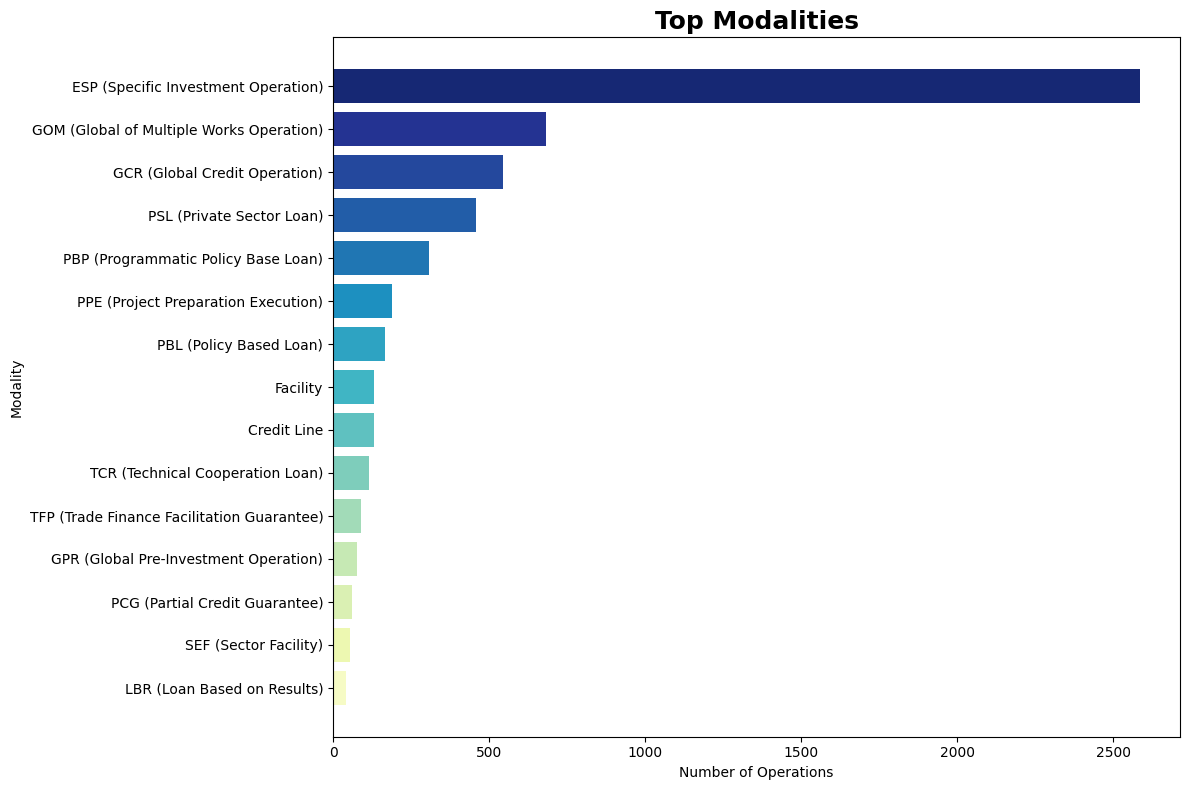

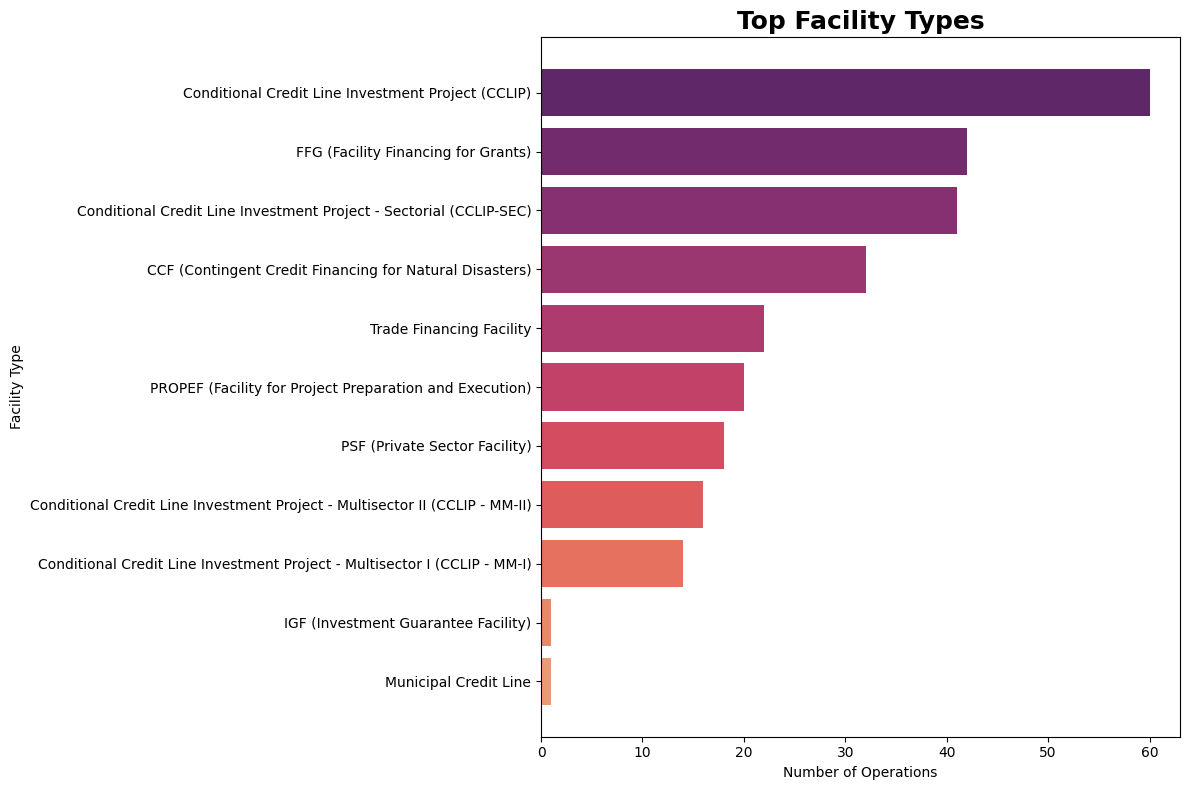

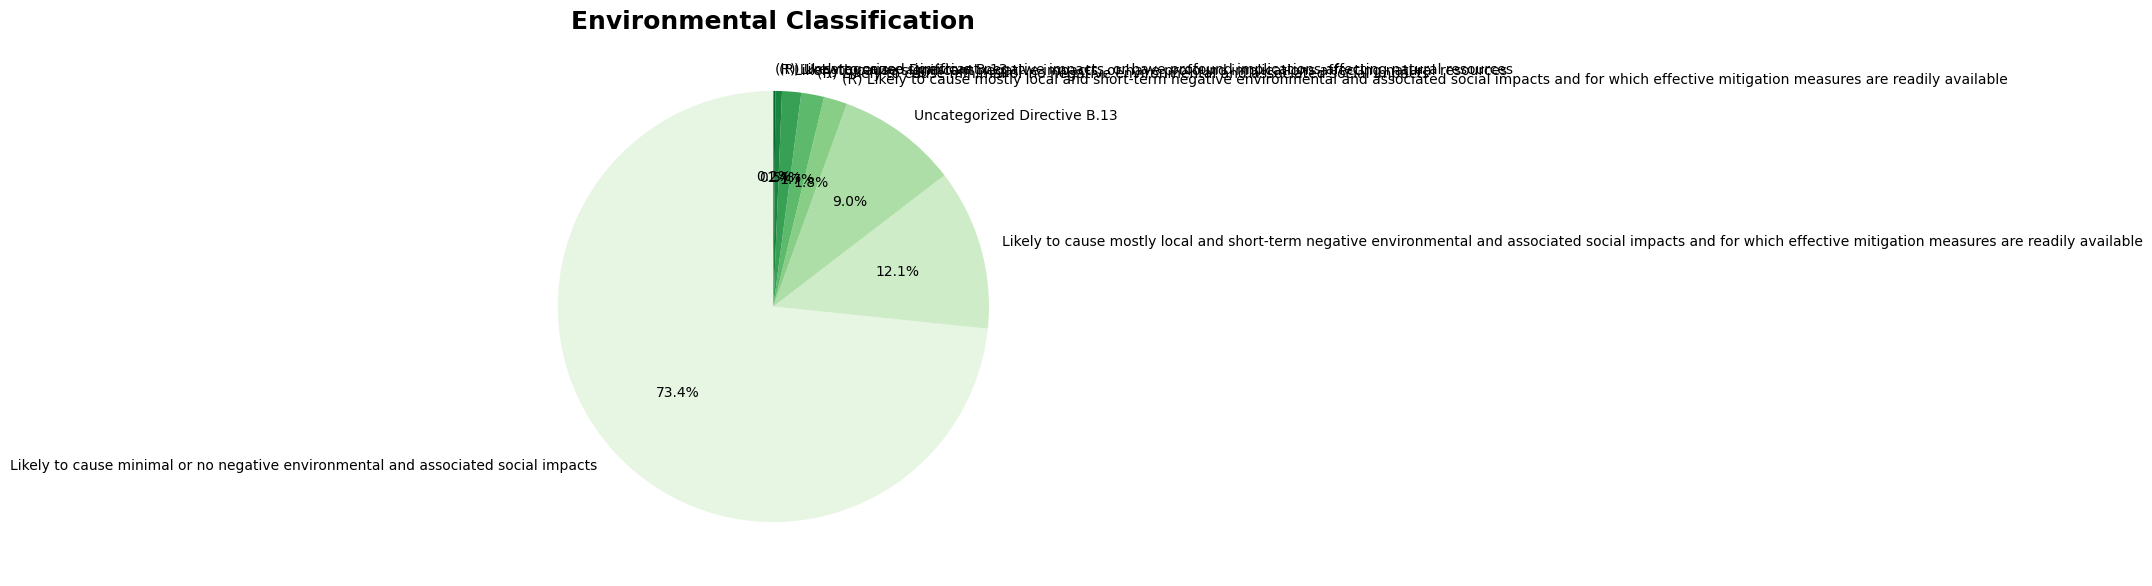

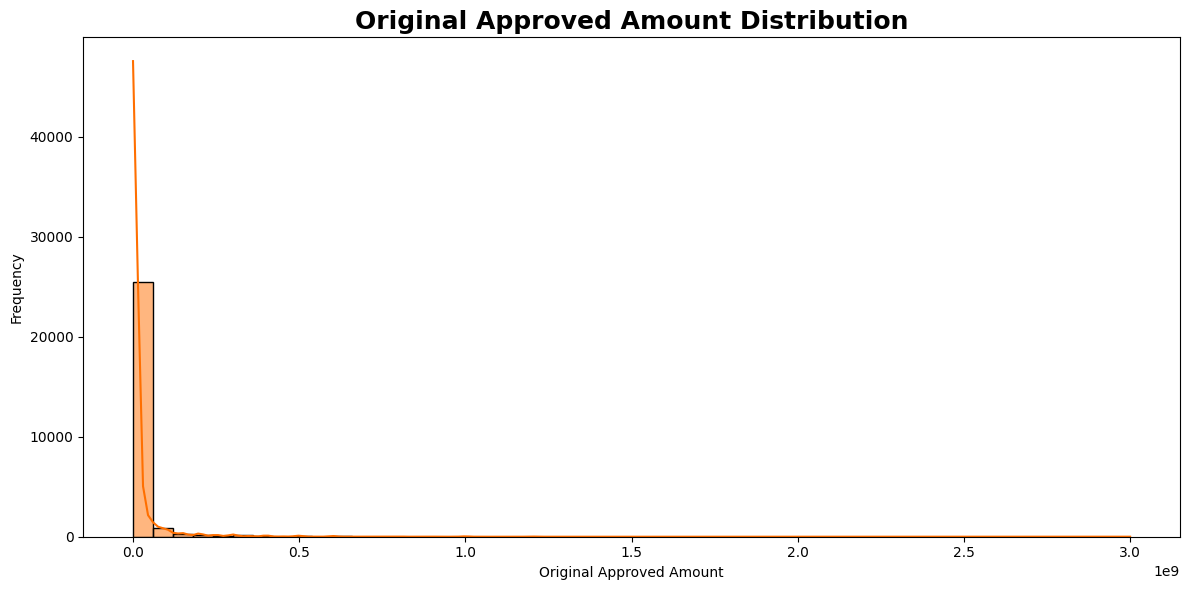

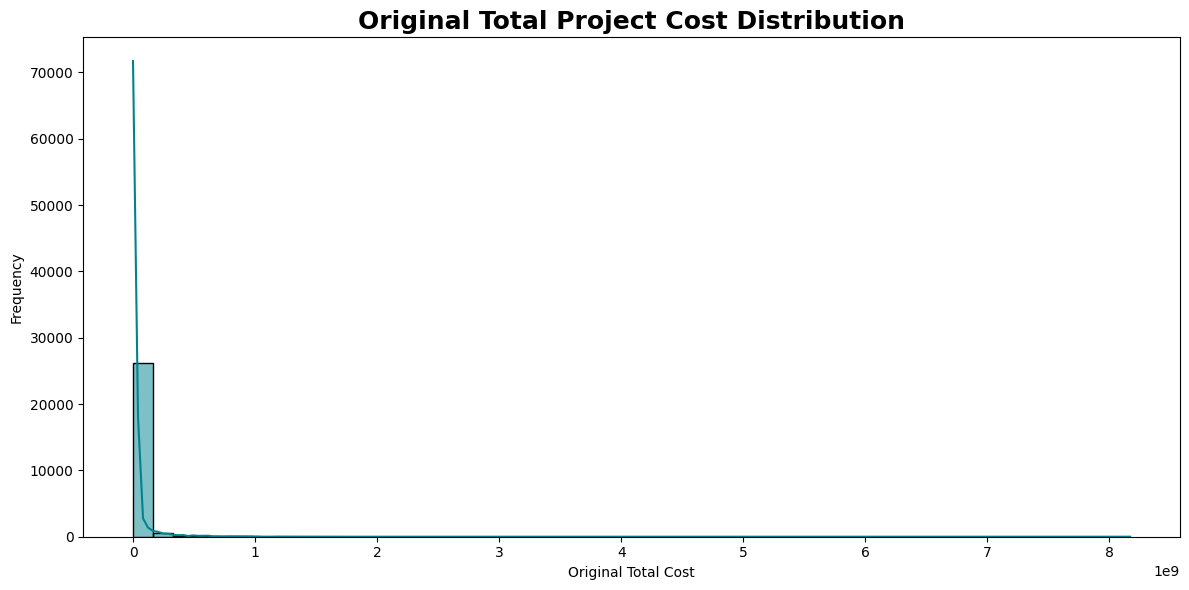

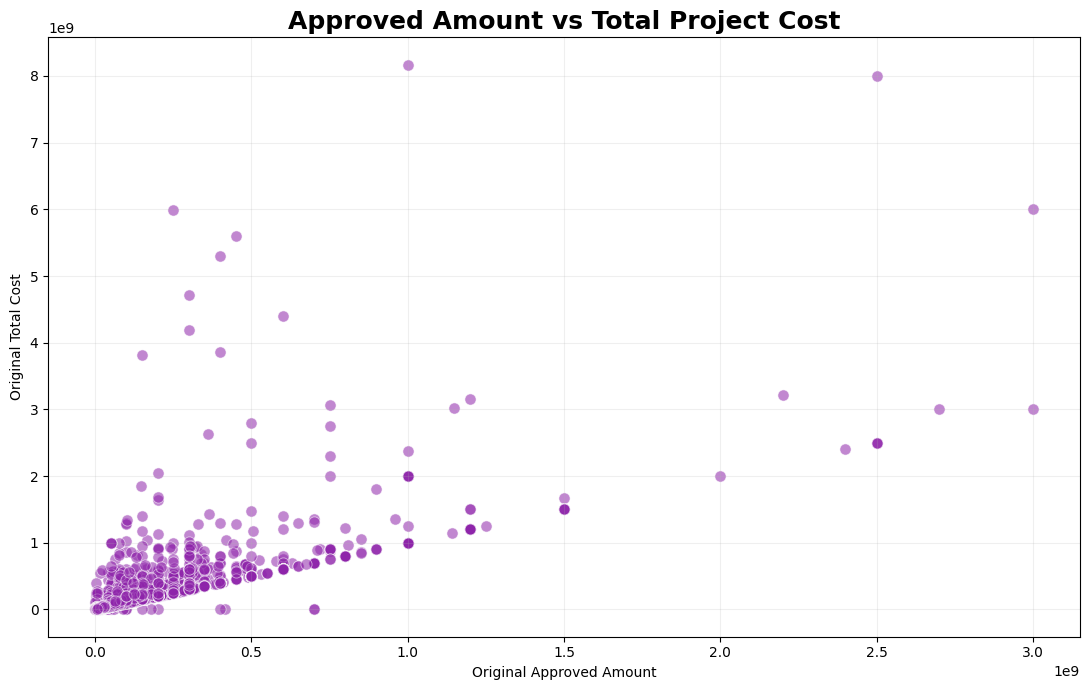

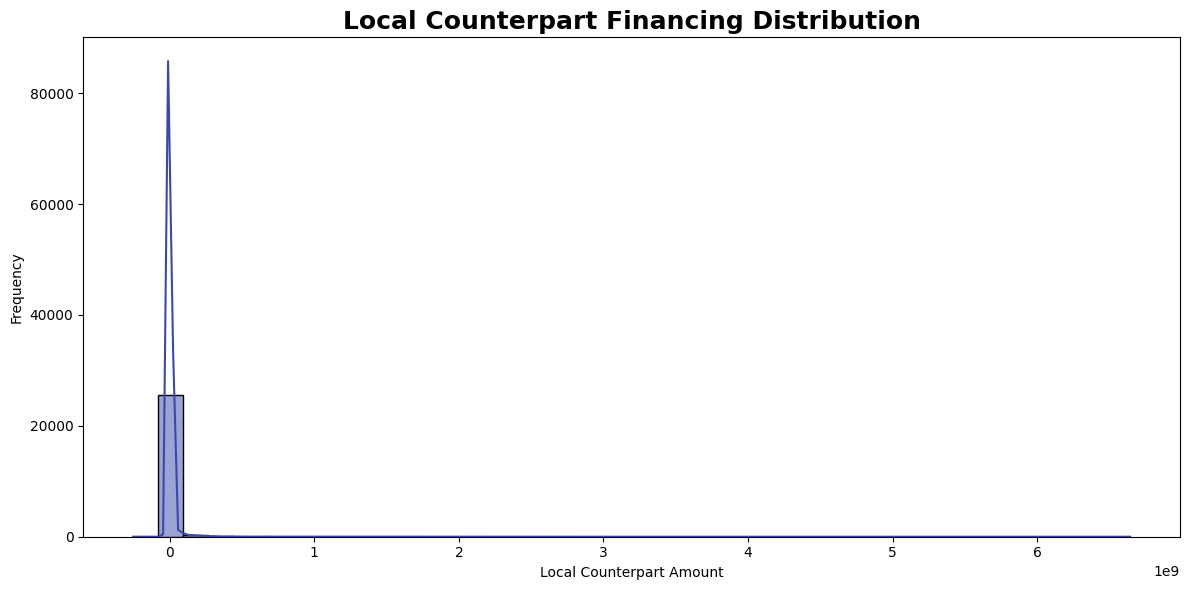

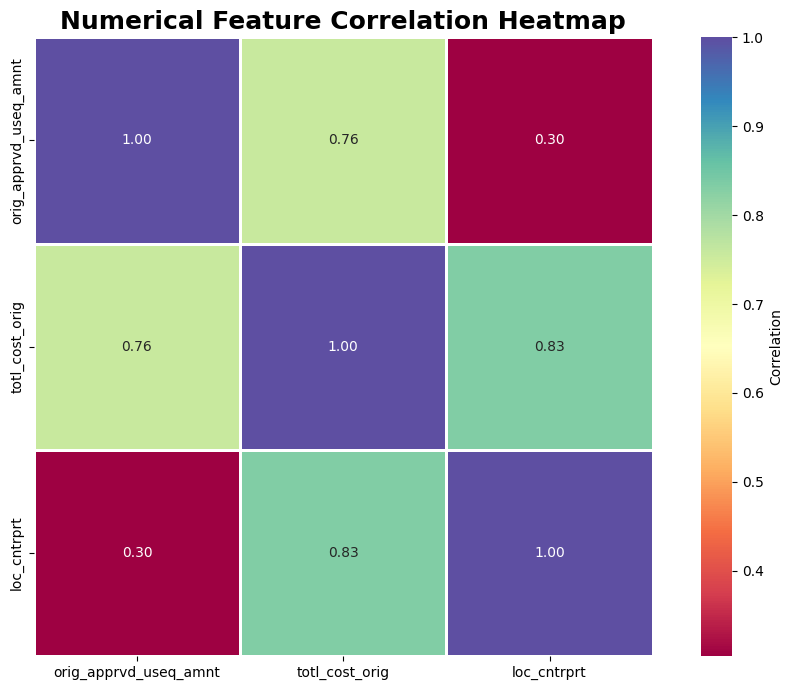

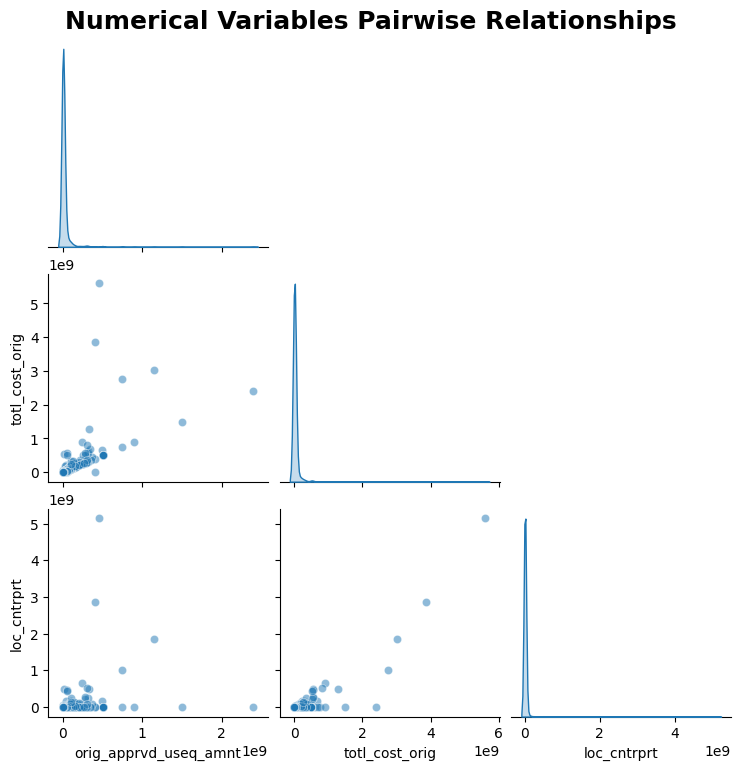

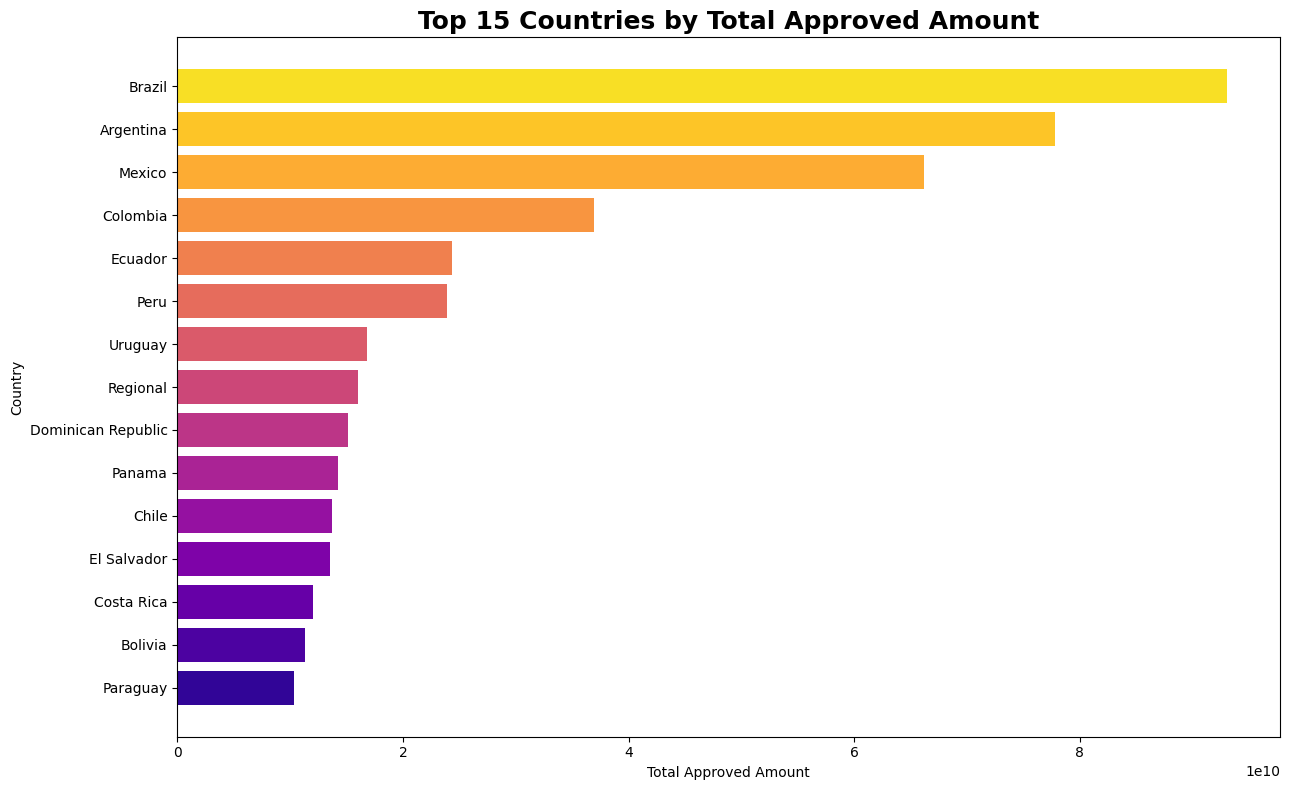

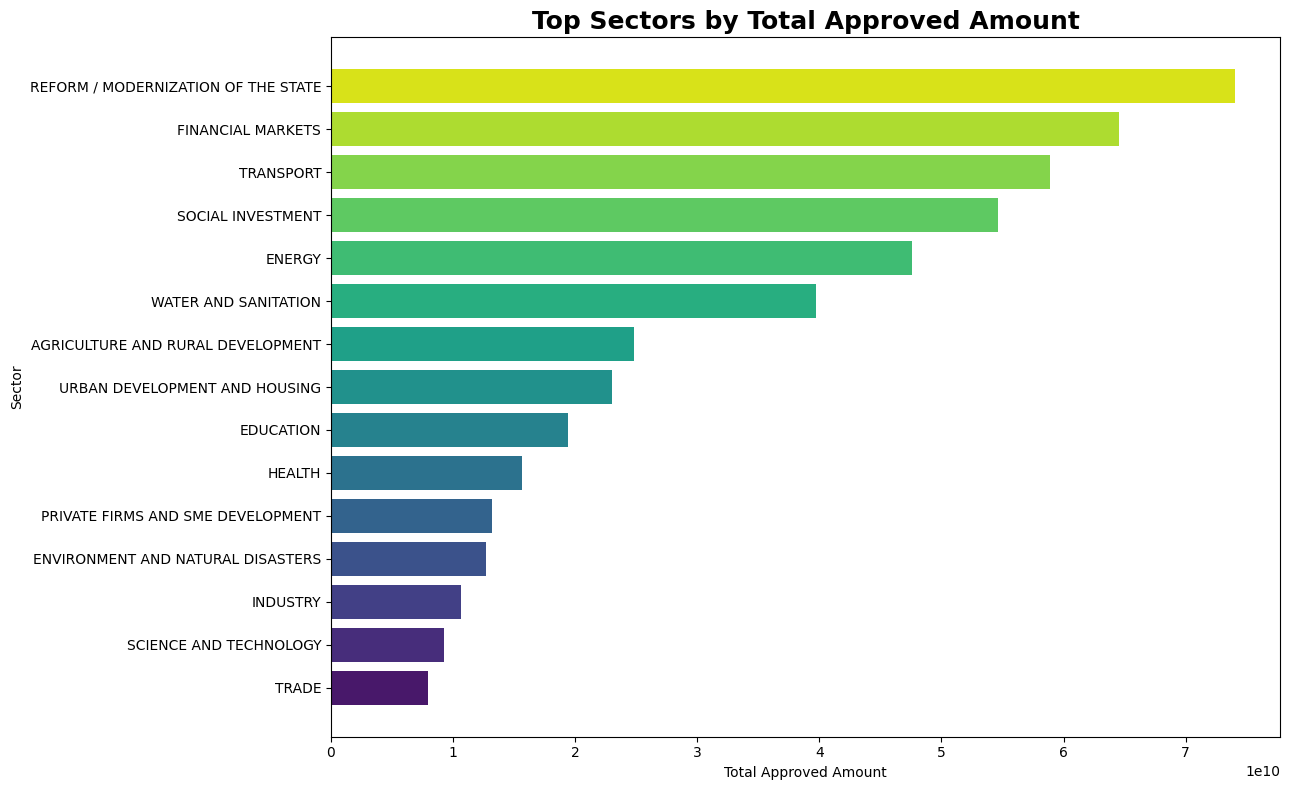

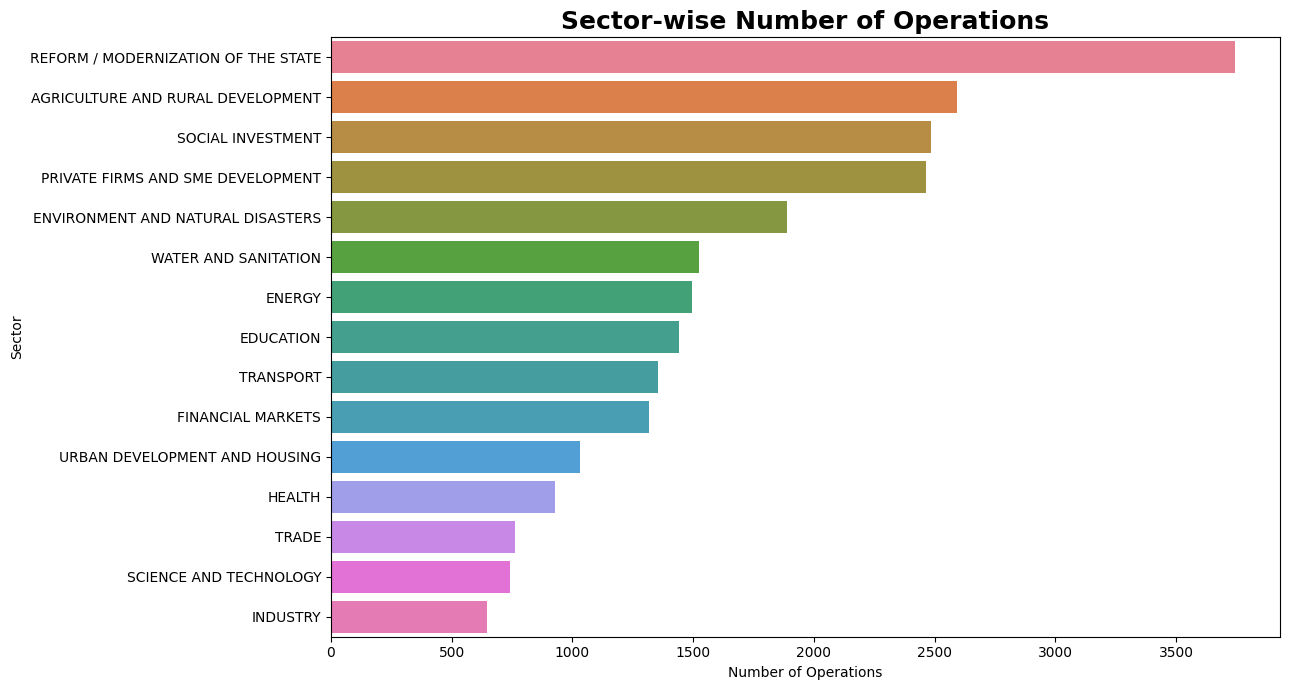

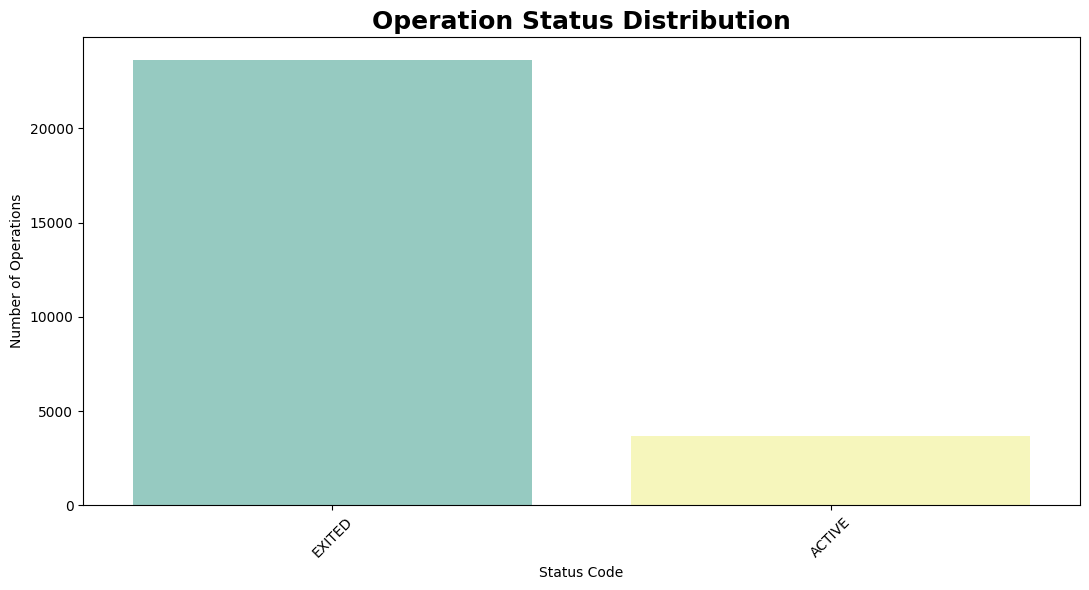

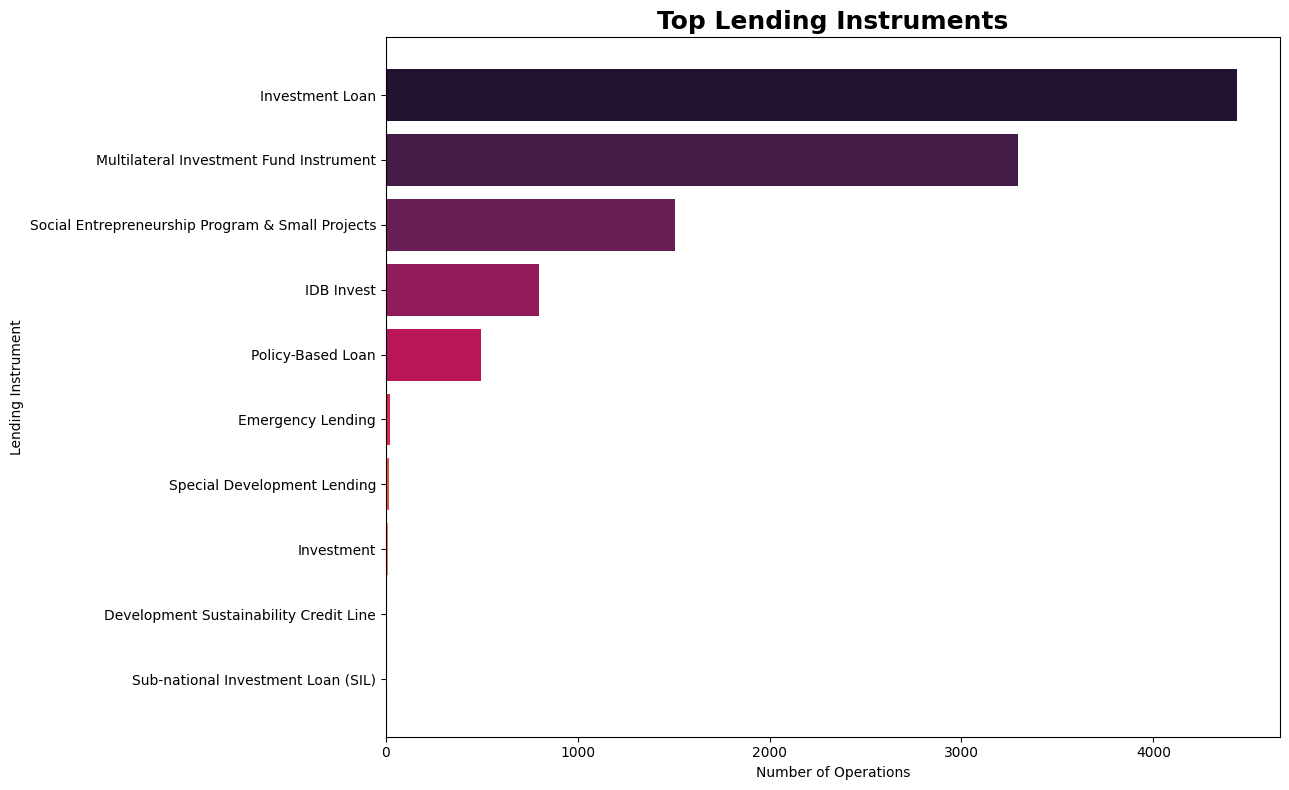

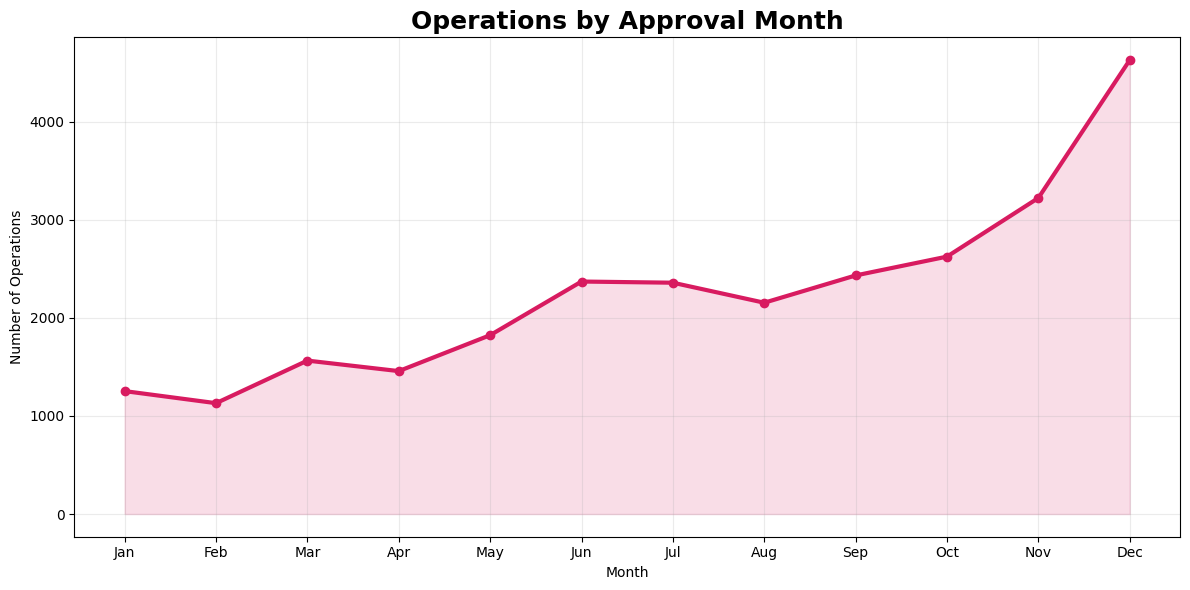

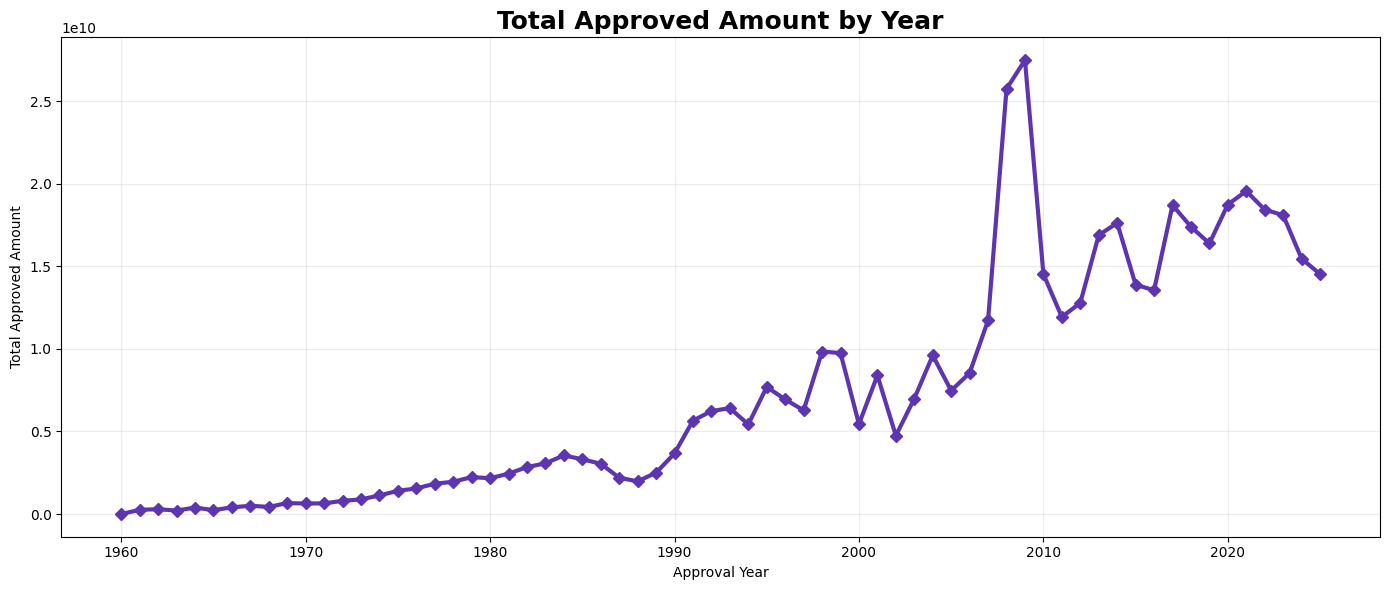

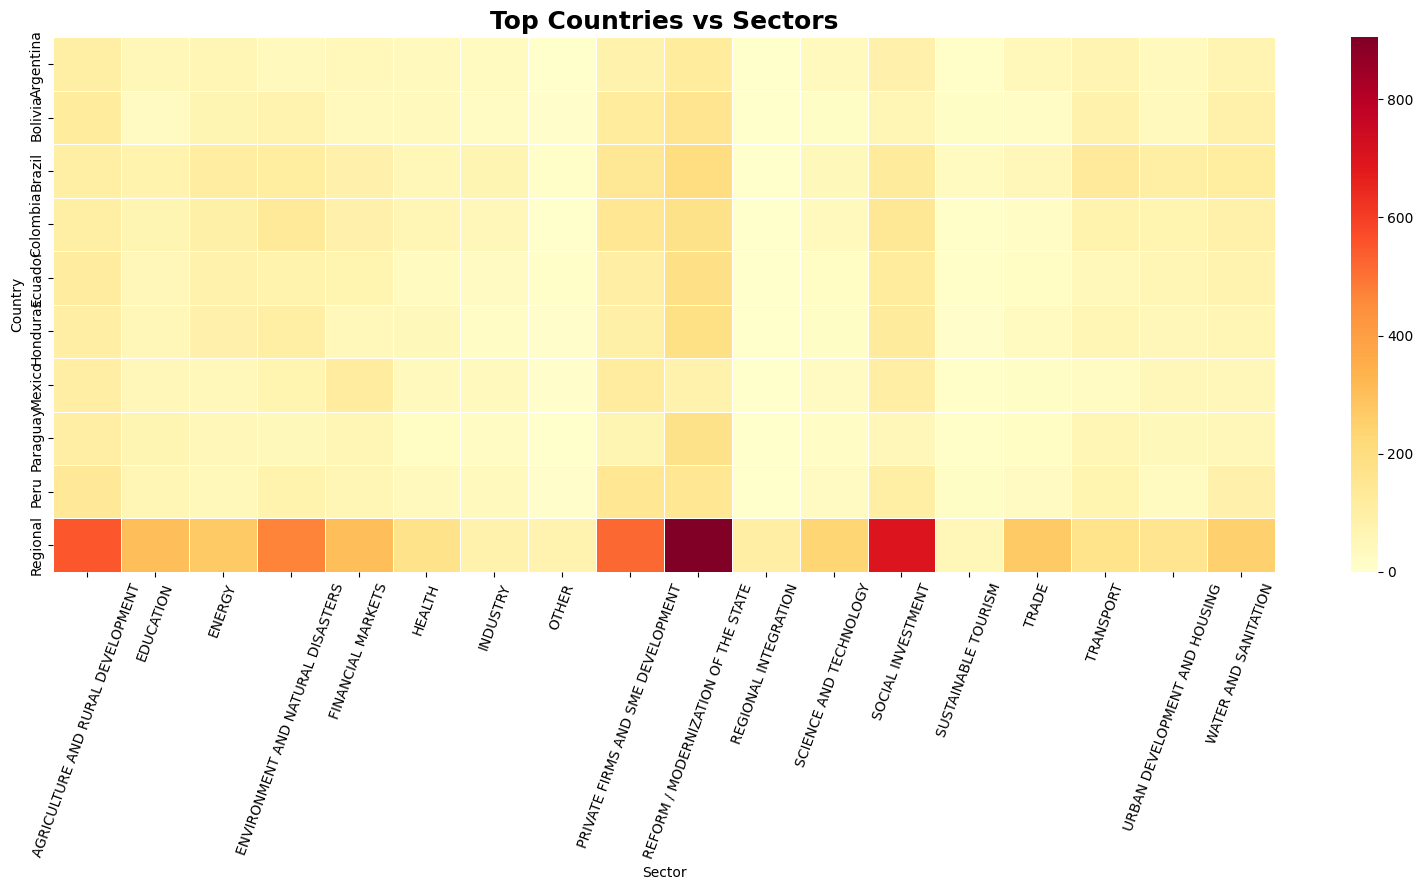

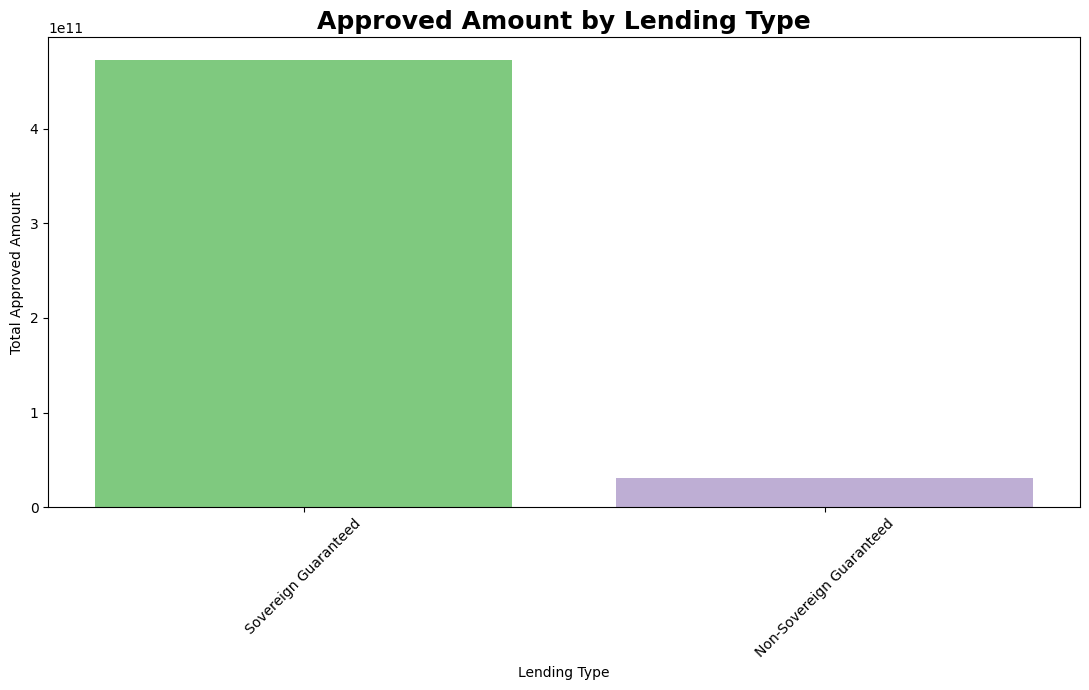

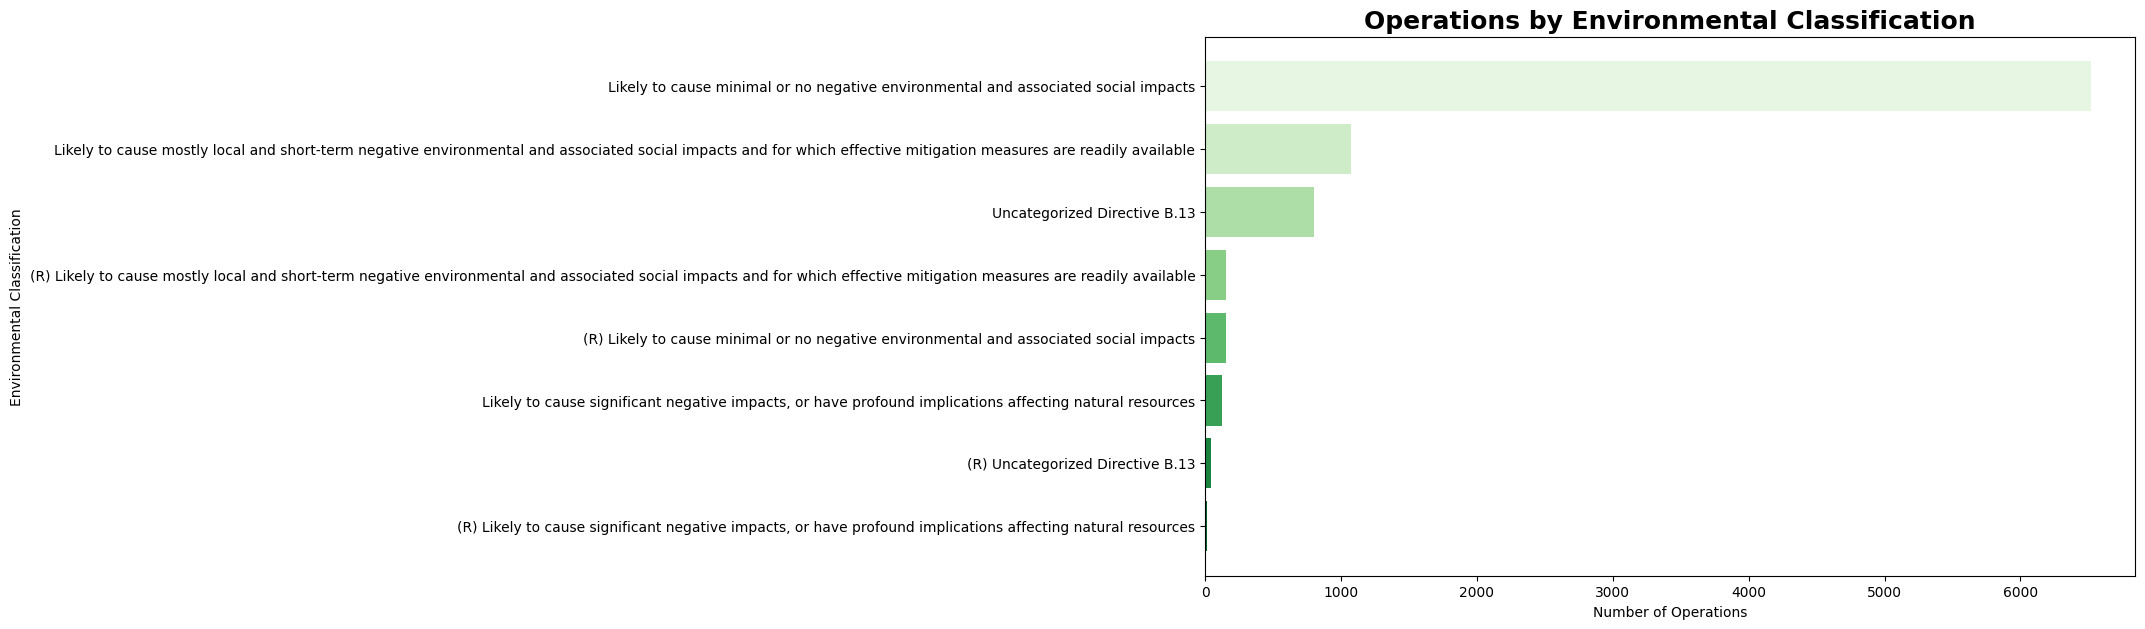



NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
orig_apprvd_useq_amnt,27329.0,1.840797e+07,9.061413e+07,0.0,120000.0,350000.0,1500000.0,3.000000e+09
totl_cost_orig,27286.0,2.755034e+07,1.666248e+08,0.0,140000.0,429500.0,2050000.0,8.170000e+09
loc_cntrprt,25899.0,7.939353e+06,1.046679e+08,-254000000.0,0.0,0.0,145000.0,6.643000e+09




TOP CATEGORIES

--- cntry_nm ---


,Count
cntry_nm,
Regional,6184
Brazil,1678
Colombia,1461
Peru,1249
Ecuador,1228
Honduras,1172
Bolivia,1086
Mexico,1058
Argentina,1022



--- sector_nm ---


...


--- facility_typ_nm ---


,Count
facility_typ_nm,
Conditional Credit Line Investment Project (CCLIP),60
FFG (Facility Financing for Grants),42
Conditional Credit Line Investment Project - Sectorial (CCLIP-SEC),41
CCF (Contingent Credit Financing for Natural Disasters),32
Trade Financing Facility,22
PROPEF (Facility for Project Preparation and Execution),20
PSF (Private Sector Facility),18
Conditional Credit Line Investment Project - Multisector II (CCLIP - MM-II),16
Conditional Credit Line Investment Project - Multisector I (CCLIP - MM-I),14



--- envmntl_clssfctn_nm ---


,Count
envmntl_clssfctn_nm,
Likely to cause minimal or no negative environmental and associated social impacts,6517
Likely to cause mostly local and short-term negative environmental and associated social impacts and for which effective mitigation measures are readily available,1071
Uncategorized Directive B.13,804
(R) Likely to cause mostly local and short-term negative environmental and associated social impacts and for which effective mitigation measures are readily available,156
(R) Likely to cause minimal or no negative environmental and associated social impacts,152
"Likely to cause significant negative impacts, or have profound implications affecting natural resources",127
(R) Uncategorized Directive B.13,43
"(R) Likely to cause significant negative impacts, or have profound implications affecting natural resources",14




VISUALIZATION COMPLETED


In [13]:


print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())
date_cols = [
    'apprvl_dt',
    'sign_dt'
]

categorical_cols = [
    'cntry_cd',
    'cntry_nm',
    'publc_sts_nm',
    'sector_cd',
    'sector_nm',
    'subsector_cd',
    'subsector_nm',
    'oper_typ_cd',
    'opertyp_nm',
    'lending_typ_nm',
    'modality_cd',
    'modality_nm',
    'facility_typ_cd',
    'facility_typ_nm',
    'envmntl_clssfctn_cd',
    'envmntl_clssfctn_nm',
    'lending_instrmnt_cd',
    'lending_instrmnt_nm',
    'lending_typ_cd',
    'sts_cd'
]

numeric_cols = [
    'orig_apprvd_useq_amnt',
    'totl_cost_orig',
    'loc_cntrprt'
]


# ------------------------------------------------
# 3. CONVERT DATE COLUMNS
# ------------------------------------------------

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col],
            errors='coerce'
        )

print("\nDate columns converted successfully.")


# ================================================================
# 4. MISSING VALUES VISUALIZATION
# ================================================================

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:

    plt.figure(figsize=(14, 7))

    bars = plt.bar(
        missing.index,
        missing.values,
        color=sns.color_palette("viridis", len(missing))
    )

    plt.title(
        "Missing Values by Column",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")

    plt.xticks(
        rotation=75,
        ha="right"
    )

    for bar, value in zip(bars, missing.values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            str(value),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# ================================================================
# 5. DATA TYPE DISTRIBUTION
# ================================================================

dtype_counts = df.dtypes.astype(str).value_counts()

plt.figure(figsize=(9, 6))

plt.pie(
    dtype_counts.values,
    labels=dtype_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(dtype_counts))
)

plt.title(
    "Distribution of Data Types",
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ================================================================
# 6. NUMERICAL DISTRIBUTIONS
# ================================================================

for col in numeric_cols:

    if col not in df.columns:
        continue

    plt.figure(figsize=(11, 6))

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=40,
        color="#6A1B9A",
        edgecolor="black"
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 7. BOX PLOTS FOR OUTLIER DETECTION
# ================================================================

for col in numeric_cols:

    if col not in df.columns:
        continue

    plt.figure(figsize=(12, 5))

    sns.boxplot(
        x=df[col],
        color="#00897B",
        linewidth=2
    )

    plt.title(
        f"Outlier Detection - {col}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ================================================================
# 8. APPROVAL DATE TREND
# ================================================================

if 'apprvl_dt' in df.columns:

    approval_year = (
        df.dropna(subset=['apprvl_dt'])
        .groupby(df['apprvl_dt'].dt.year)
        .size()
    )

    plt.figure(figsize=(13, 6))

    plt.plot(
        approval_year.index,
        approval_year.values,
        marker="o",
        linewidth=3,
        color="#E53935"
    )

    plt.fill_between(
        approval_year.index,
        approval_year.values,
        alpha=0.15,
        color="#E53935"
    )

    plt.title(
        "Projects Approved Over Time",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Approval Year")
    plt.ylabel("Number of Projects")

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ================================================================
# 9. SIGNING DATE TREND
# ================================================================

if 'sign_dt' in df.columns:

    sign_year = (
        df.dropna(subset=['sign_dt'])
        .groupby(df['sign_dt'].dt.year)
        .size()
    )

    plt.figure(figsize=(13, 6))

    plt.plot(
        sign_year.index,
        sign_year.values,
        marker="s",
        linewidth=3,
        color="#1E88E5"
    )

    plt.fill_between(
        sign_year.index,
        sign_year.values,
        alpha=0.15,
        color="#1E88E5"
    )

    plt.title(
        "Projects Signed Over Time",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Signing Year")
    plt.ylabel("Number of Projects")

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ================================================================
# 10. TOP 15 COUNTRIES
# ================================================================

if 'cntry_nm' in df.columns:

    country_counts = (
        df['cntry_nm']
        .value_counts()
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        country_counts.index,
        country_counts.values,
        color=sns.color_palette(
            "magma",
            len(country_counts)
        )
    )

    plt.title(
        "Top 15 Countries by Number of Operations",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Country")

    for bar, value in zip(
        bars,
        country_counts.values
    ):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f" {value}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ================================================================
# 11. TOP 15 COUNTRIES - PIE CHART
# ================================================================

if 'cntry_nm' in df.columns:

    country_pie = (
        df['cntry_nm']
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 10))

    plt.pie(
        country_pie.values,
        labels=country_pie.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=sns.color_palette(
            "tab10",
            len(country_pie)
        ),
        wedgeprops={
            "edgecolor": "white",
            "linewidth": 1.5
        }
    )

    plt.title(
        "Top 10 Countries - Operation Share",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ================================================================
# 12. SECTOR DISTRIBUTION
# ================================================================

if 'sector_nm' in df.columns:

    sector_counts = (
        df['sector_nm']
        .value_counts()
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(13, 8))

    plt.barh(
        sector_counts.index,
        sector_counts.values,
        color=sns.color_palette(
            "cool",
            len(sector_counts)
        )
    )

    plt.title(
        "Operations by Sector",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Sector")

    plt.tight_layout()
    plt.show()


# ================================================================
# 13. SUBSECTOR DISTRIBUTION
# ================================================================

if 'subsector_nm' in df.columns:

    subsector_counts = (
        df['subsector_nm']
        .value_counts()
        .head(20)
        .sort_values()
    )

    plt.figure(figsize=(13, 9))

    plt.barh(
        subsector_counts.index,
        subsector_counts.values,
        color=sns.color_palette(
            "cubehelix",
            len(subsector_counts)
        )
    )

    plt.title(
        "Top 20 Operations by Subsector",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Subsector")

    plt.tight_layout()
    plt.show()


# ================================================================
# 14. PUBLIC STATUS DISTRIBUTION
# ================================================================

if 'publc_sts_nm' in df.columns:

    status_counts = df['publc_sts_nm'].value_counts()

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=status_counts.values,
        y=status_counts.index,
        hue=status_counts.index,
        palette="Spectral",
        legend=False
    )

    plt.title(
        "Operations by Public Status",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Public Status")

    plt.tight_layout()
    plt.show()


# ================================================================
# 15. OPERATION TYPE
# ================================================================

if 'opertyp_nm' in df.columns:

    operation_type = df['opertyp_nm'].value_counts()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=operation_type.values,
        y=operation_type.index,
        hue=operation_type.index,
        palette="rocket",
        legend=False
    )

    plt.title(
        "Operations by Operation Type",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Operation Type")

    plt.tight_layout()
    plt.show()


# ================================================================
# 16. LENDING TYPE
# ================================================================

if 'lending_typ_nm' in df.columns:

    lending = df['lending_typ_nm'].value_counts()

    plt.figure(figsize=(9, 7))

    plt.pie(
        lending.values,
        labels=lending.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "Paired",
            len(lending)
        )
    )

    plt.title(
        "Distribution of Lending Types",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ================================================================
# 17. MODALITY DISTRIBUTION
# ================================================================

if 'modality_nm' in df.columns:

    modality = (
        df['modality_nm']
        .value_counts()
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(12, 8))

    plt.barh(
        modality.index,
        modality.values,
        color=sns.color_palette(
            "YlGnBu",
            len(modality)
        )
    )

    plt.title(
        "Top Modalities",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Modality")

    plt.tight_layout()
    plt.show()


# ================================================================
# 18. FACILITY TYPE
# ================================================================

if 'facility_typ_nm' in df.columns:

    facility = (
        df['facility_typ_nm']
        .value_counts()
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(12, 8))

    plt.barh(
        facility.index,
        facility.values,
        color=sns.color_palette(
            "flare",
            len(facility)
        )
    )

    plt.title(
        "Top Facility Types",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Facility Type")

    plt.tight_layout()
    plt.show()


# ================================================================
# 19. ENVIRONMENTAL CLASSIFICATION
# ================================================================

if 'envmntl_clssfctn_nm' in df.columns:

    env = (
        df['envmntl_clssfctn_nm']
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 7))

    plt.pie(
        env.values,
        labels=env.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "Greens",
            len(env)
        )
    )

    plt.title(
        "Environmental Classification",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ================================================================
# 20. APPROVED AMOUNT DISTRIBUTION
# ================================================================

if 'orig_apprvd_useq_amnt' in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df['orig_apprvd_useq_amnt'].dropna(),
        bins=50,
        kde=True,
        color="#FF6F00",
        edgecolor="black"
    )

    plt.title(
        "Original Approved Amount Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Original Approved Amount")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ================================================================
# 21. PROJECT COST DISTRIBUTION
# ================================================================

if 'totl_cost_orig' in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df['totl_cost_orig'].dropna(),
        bins=50,
        kde=True,
        color="#00838F",
        edgecolor="black"
    )

    plt.title(
        "Original Total Project Cost Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Original Total Cost")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ================================================================
# 22. APPROVED AMOUNT VS TOTAL COST
# ================================================================

if (
    'orig_apprvd_useq_amnt' in df.columns
    and 'totl_cost_orig' in df.columns
):

    plot_df = df[
        [
            'orig_apprvd_useq_amnt',
            'totl_cost_orig'
        ]
    ].dropna()

    # Remove infinite values
    plot_df = plot_df[
        np.isfinite(
            plot_df['orig_apprvd_useq_amnt']
        )
        &
        np.isfinite(
            plot_df['totl_cost_orig']
        )
    ]

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=plot_df,
        x='orig_apprvd_useq_amnt',
        y='totl_cost_orig',
        alpha=0.55,
        s=65,
        color="#8E24AA"
    )

    plt.title(
        "Approved Amount vs Total Project Cost",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Original Approved Amount")
    plt.ylabel("Original Total Cost")

    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


# ================================================================
# 23. LOCAL COUNTERPART FINANCING
# ================================================================

if 'loc_cntrprt' in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df['loc_cntrprt'].dropna(),
        bins=40,
        kde=True,
        color="#3949AB",
        edgecolor="black"
    )

    plt.title(
        "Local Counterpart Financing Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Local Counterpart Amount")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ================================================================
# 24. CORRELATION HEATMAP
# ================================================================

available_numeric = [
    col for col in numeric_cols
    if col in df.columns
]

if len(available_numeric) >= 2:

    correlation = df[
        available_numeric
    ].corr()

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="Spectral",
        linewidths=1,
        square=True,
        cbar_kws={
            "label": "Correlation"
        }
    )

    plt.title(
        "Numerical Feature Correlation Heatmap",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# 25. NUMERICAL PAIRPLOT
# ================================================================

if len(available_numeric) >= 2:

    pair_data = df[
        available_numeric
    ].dropna()

    # Limit rows for faster visualization
    if len(pair_data) > 2000:
        pair_data = pair_data.sample(
            2000,
            random_state=42
        )

    sns.pairplot(
        pair_data,
        diag_kind="kde",
        corner=True,
        plot_kws={
            "alpha": 0.5,
            "s": 35
        }
    )

    plt.suptitle(
        "Numerical Variables Pairwise Relationships",
        y=1.02,
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ================================================================
# 26. TOP COUNTRIES BY APPROVED AMOUNT
# ================================================================

if (
    'cntry_nm' in df.columns
    and 'orig_apprvd_useq_amnt' in df.columns
):

    country_amount = (
        df.groupby('cntry_nm')
        ['orig_apprvd_useq_amnt']
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(13, 8))

    bars = plt.barh(
        country_amount.index,
        country_amount.values,
        color=sns.color_palette(
            "plasma",
            len(country_amount)
        )
    )

    plt.title(
        "Top 15 Countries by Total Approved Amount",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Approved Amount")
    plt.ylabel("Country")

    plt.tight_layout()
    plt.show()


# ================================================================
# 27. SECTOR VS APPROVED AMOUNT
# ================================================================

if (
    'sector_nm' in df.columns
    and 'orig_apprvd_useq_amnt' in df.columns
):

    sector_amount = (
        df.groupby('sector_nm')
        ['orig_apprvd_useq_amnt']
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(13, 8))

    plt.barh(
        sector_amount.index,
        sector_amount.values,
        color=sns.color_palette(
            "viridis",
            len(sector_amount)
        )
    )

    plt.title(
        "Top Sectors by Total Approved Amount",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Total Approved Amount")
    plt.ylabel("Sector")

    plt.tight_layout()
    plt.show()


# ================================================================
# 28. SECTOR VS PROJECT COUNT
# ================================================================

if 'sector_nm' in df.columns:

    sector_count = (
        df['sector_nm']
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(13, 7))

    sns.barplot(
        x=sector_count.values,
        y=sector_count.index,
        hue=sector_count.index,
        palette="husl",
        legend=False
    )

    plt.title(
        "Sector-wise Number of Operations",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Sector")

    plt.tight_layout()
    plt.show()


# ================================================================
# 29. OPERATION STATUS
# ================================================================

if 'sts_cd' in df.columns:

    operation_status = (
        df['sts_cd']
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=operation_status.index,
        y=operation_status.values,
        hue=operation_status.index,
        palette="Set3",
        legend=False
    )

    plt.title(
        "Operation Status Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Status Code")
    plt.ylabel("Number of Operations")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ================================================================
# 30. LENDING INSTRUMENT
# ================================================================

if 'lending_instrmnt_nm' in df.columns:

    lending_instrument = (
        df['lending_instrmnt_nm']
        .value_counts()
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(13, 8))

    plt.barh(
        lending_instrument.index,
        lending_instrument.values,
        color=sns.color_palette(
            "rocket_r",
            len(lending_instrument)
        )
    )

    plt.title(
        "Top Lending Instruments",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Lending Instrument")

    plt.tight_layout()
    plt.show()


# ================================================================
# 31. APPROVAL MONTH DISTRIBUTION
# ================================================================

if 'apprvl_dt' in df.columns:

    month_counts = (
        df['apprvl_dt']
        .dt.month
        .value_counts()
        .sort_index()
    )

    month_names = [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]

    plt.figure(figsize=(12, 6))

    plt.plot(
        month_counts.index,
        month_counts.values,
        marker="o",
        linewidth=3,
        color="#D81B60"
    )

    plt.fill_between(
        month_counts.index,
        month_counts.values,
        alpha=0.15,
        color="#D81B60"
    )

    plt.xticks(
        range(1, 13),
        month_names
    )

    plt.title(
        "Operations by Approval Month",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Month")
    plt.ylabel("Number of Operations")

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ================================================================
# 32. APPROVAL YEAR VS APPROVED AMOUNT
# ================================================================

if (
    'apprvl_dt' in df.columns
    and 'orig_apprvd_useq_amnt' in df.columns
):

    yearly_amount = (
        df.dropna(subset=['apprvl_dt'])
        .groupby(
            df['apprvl_dt'].dt.year
        )['orig_apprvd_useq_amnt']
        .sum()
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        yearly_amount.index,
        yearly_amount.values,
        marker="D",
        linewidth=3,
        color="#5E35B1"
    )

    plt.title(
        "Total Approved Amount by Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Approval Year")
    plt.ylabel("Total Approved Amount")

    plt.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


# ================================================================
# 33. TOP 10 COUNTRIES + SECTOR CROSS TAB
# ================================================================

if (
    'cntry_nm' in df.columns
    and 'sector_nm' in df.columns
):

    top_countries = (
        df['cntry_nm']
        .value_counts()
        .head(10)
        .index
    )

    cross_data = df[
        df['cntry_nm'].isin(top_countries)
    ]

    cross_tab = pd.crosstab(
        cross_data['cntry_nm'],
        cross_data['sector_nm']
    )

    plt.figure(figsize=(16, 9))

    sns.heatmap(
        cross_tab,
        cmap="YlOrRd",
        linewidths=0.5
    )

    plt.title(
        "Top Countries vs Sectors",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Sector")
    plt.ylabel("Country")

    plt.xticks(rotation=70)

    plt.tight_layout()
    plt.show()


# ================================================================
# 34. APPROVED AMOUNT BY LENDING TYPE
# ================================================================

if (
    'lending_typ_nm' in df.columns
    and 'orig_apprvd_useq_amnt' in df.columns
):

    lending_amount = (
        df.groupby('lending_typ_nm')
        ['orig_apprvd_useq_amnt']
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(11, 7))

    bars = plt.bar(
        lending_amount.index,
        lending_amount.values,
        color=sns.color_palette(
            "Accent",
            len(lending_amount)
        )
    )

    plt.title(
        "Approved Amount by Lending Type",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Lending Type")
    plt.ylabel("Total Approved Amount")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ================================================================
# 35. ENVIRONMENTAL CLASSIFICATION VS OPERATION COUNT
# ================================================================

if 'envmntl_clssfctn_nm' in df.columns:

    environmental = (
        df['envmntl_clssfctn_nm']
        .value_counts()
        .head(10)
        .sort_values()
    )

    plt.figure(figsize=(12, 7))

    plt.barh(
        environmental.index,
        environmental.values,
        color=sns.color_palette(
            "Greens_r",
            len(environmental)
        )
    )

    plt.title(
        "Operations by Environmental Classification",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Operations")
    plt.ylabel("Environmental Classification")

    plt.tight_layout()
    plt.show()


# ================================================================
# 36. SUMMARY STATISTICS
# ================================================================

print("\n")
print("=" * 70)
print("NUMERICAL SUMMARY")
print("=" * 70)

display(
    df[available_numeric].describe().T
)


print("\n")
print("=" * 70)
print("TOP CATEGORIES")
print("=" * 70)

for col in [
    'cntry_nm',
    'sector_nm',
    'subsector_nm',
    'publc_sts_nm',
    'opertyp_nm',
    'lending_typ_nm',
    'modality_nm',
    'facility_typ_nm',
    'envmntl_clssfctn_nm'
]:

    if col in df.columns:

        print(f"\n--- {col} ---")

        display(
            df[col]
            .value_counts()
            .head(10)
            .to_frame("Count")
        )


print("\n")
print("=" * 70)
print("VISUALIZATION COMPLETED")
print("=" * 70)

## Feature engineering

ORIGINAL DATASET
Shape: (27329, 28)

Columns:
['oper_num', 'oper_nm', 'apprvl_dt', 'sign_dt', 'cntry_cd', 'cntry_nm', 'publc_sts_nm', 'sector_cd', 'sector_nm', 'subsector_cd', 'subsector_nm', 'oper_typ_cd', 'opertyp_nm', 'objtv', 'orig_apprvd_useq_amnt', 'totl_cost_orig', 'loc_cntrprt', 'lending_typ_nm', 'modality_cd', 'modality_nm', 'facility_typ_cd', 'facility_typ_nm', 'envmntl_clssfctn_cd', 'envmntl_clssfctn_nm', 'lending_instrmnt_cd', 'lending_instrmnt_nm', 'lending_typ_cd', 'sts_cd']

Duplicates removed: 0
New shape: (27329, 28)

Target column: sts_cd

Target distribution:
sts_cd
EXITED    23644
ACTIVE     3685
Name: count, dtype: int64

Shape after removing missing target:
(27329, 28)


FEATURE / TARGET SHAPE
X Shape: (27329, 32)
y Shape: (27329,)

Target Classes:
0 = ACTIVE
1 = EXITED

Categorical Features:
['oper_nm', 'cntry_cd', 'cntry_nm', 'publc_sts_nm', 'sector_cd', 'sector_nm', 'subsector_cd', 'subsector_nm', 'oper_typ_cd', 'opertyp_nm', 'lending_typ_nm', 'modality_cd', 'm

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,100.00,100.00,100.00,100.00
1,Decision Tree,100.00,100.00,100.00,100.00
2,Random Forest,100.00,100.00,100.00,100.00
3,Gradient Boosting,100.00,100.00,100.00,100.00
4,Hist Gradient Boosting,100.00,100.00,100.00,100.00
5,AdaBoost,100.00,100.00,100.00,100.00
6,Extra Trees,99.96,99.96,99.96,99.96
7,SVM,99.91,99.91,99.91,99.91
8,KNN,99.21,99.21,99.21,99.21
9,Gaussian Naive Bayes,98.65,98.76,98.65,98.67


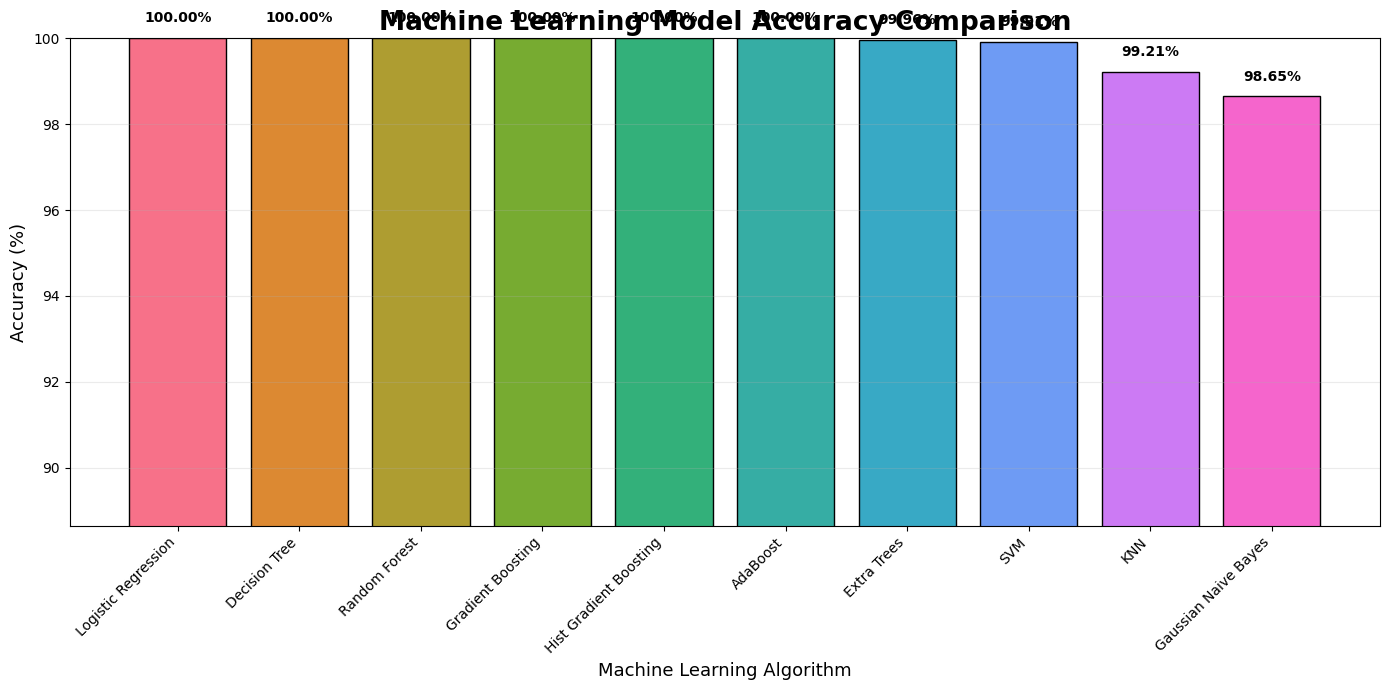

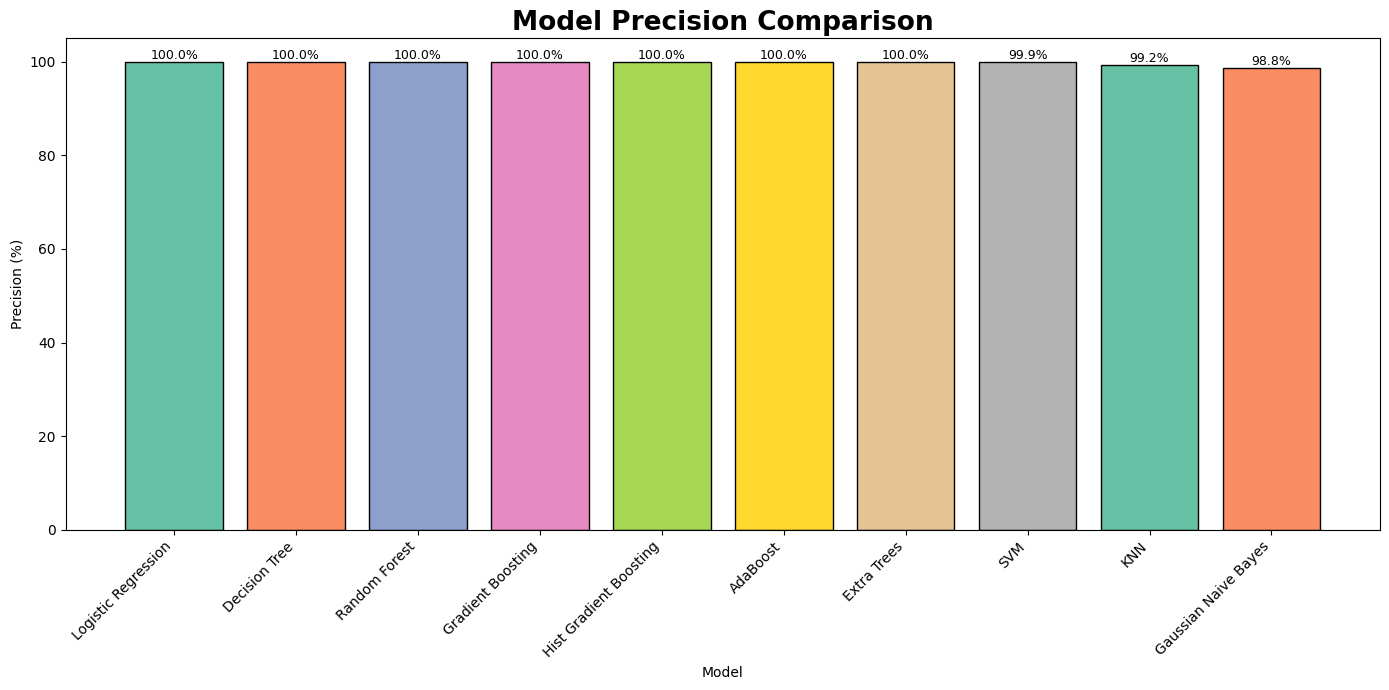

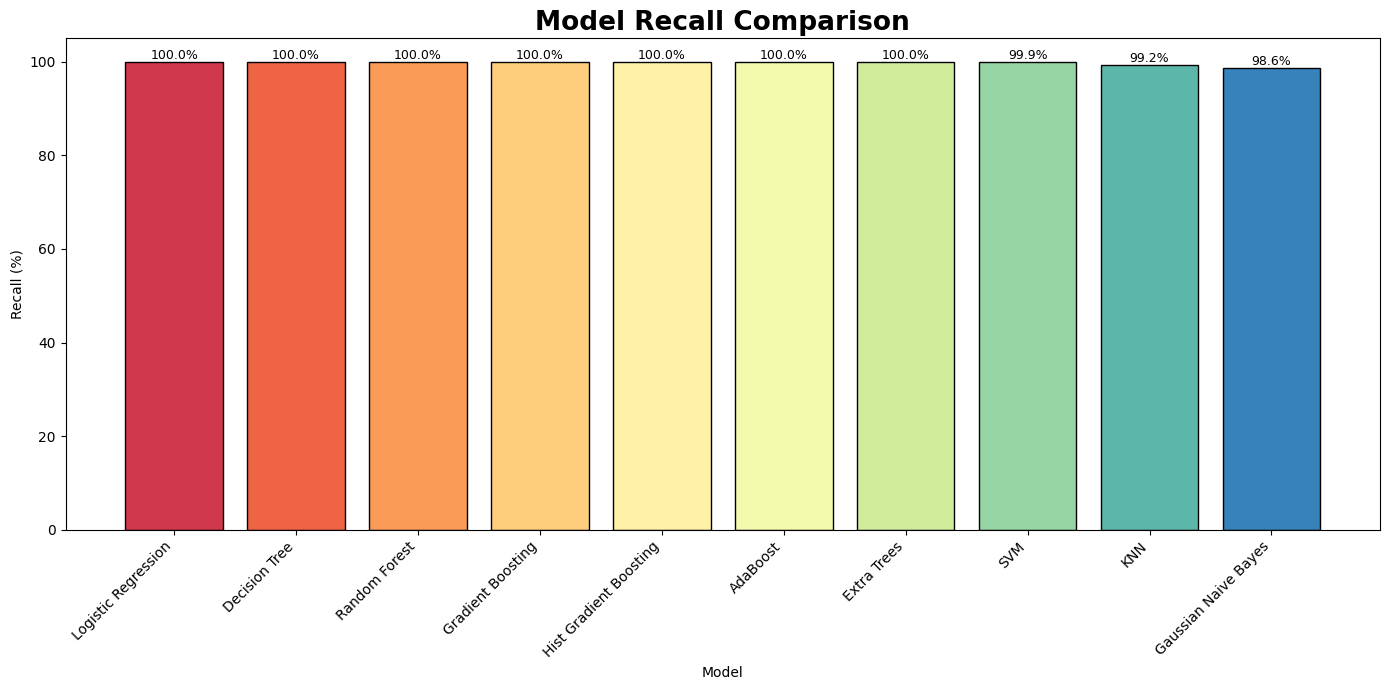

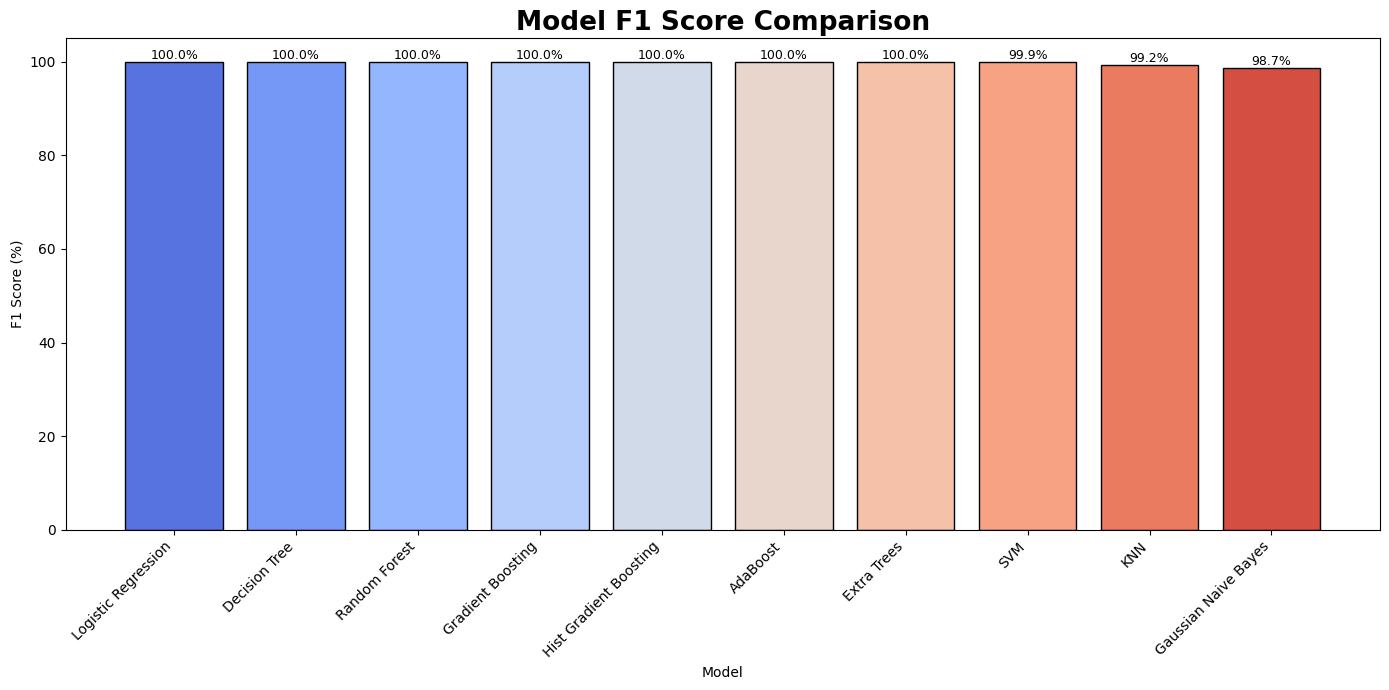



BEST MODEL
Model:
Logistic Regression
Accuracy: 100.00%


CLASSIFICATION REPORT - BEST MODEL
              precision    recall  f1-score   support

      ACTIVE       1.00      1.00      1.00       737
      EXITED       1.00      1.00      1.00      4729

    accuracy                           1.00      5466
   macro avg       1.00      1.00      1.00      5466
weighted avg       1.00      1.00      1.00      5466



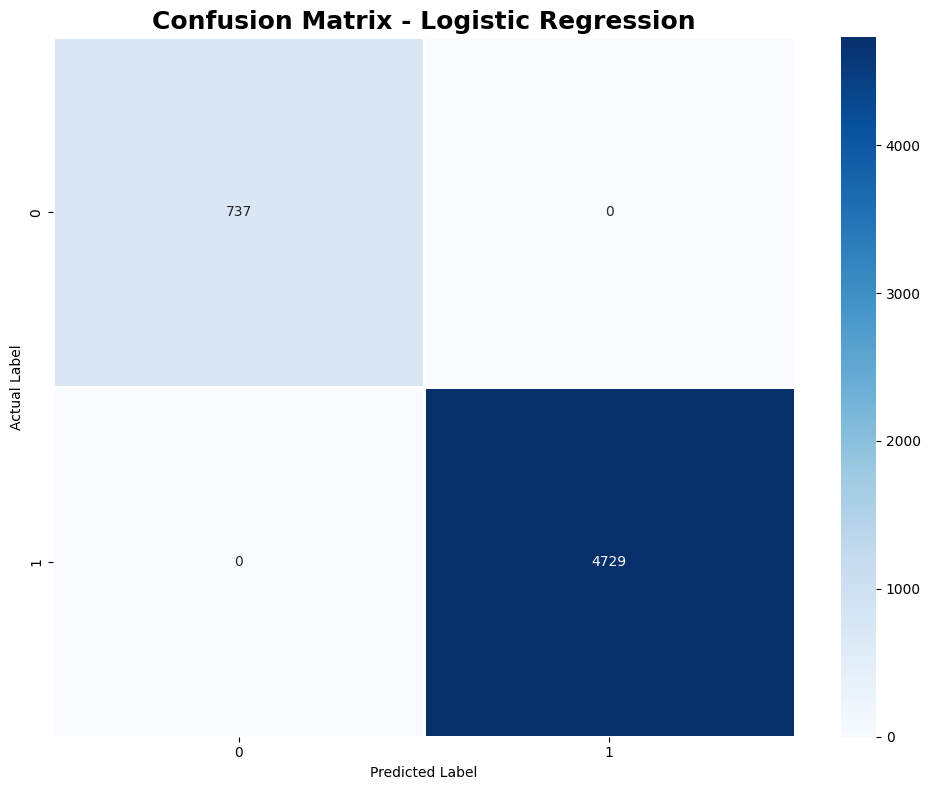

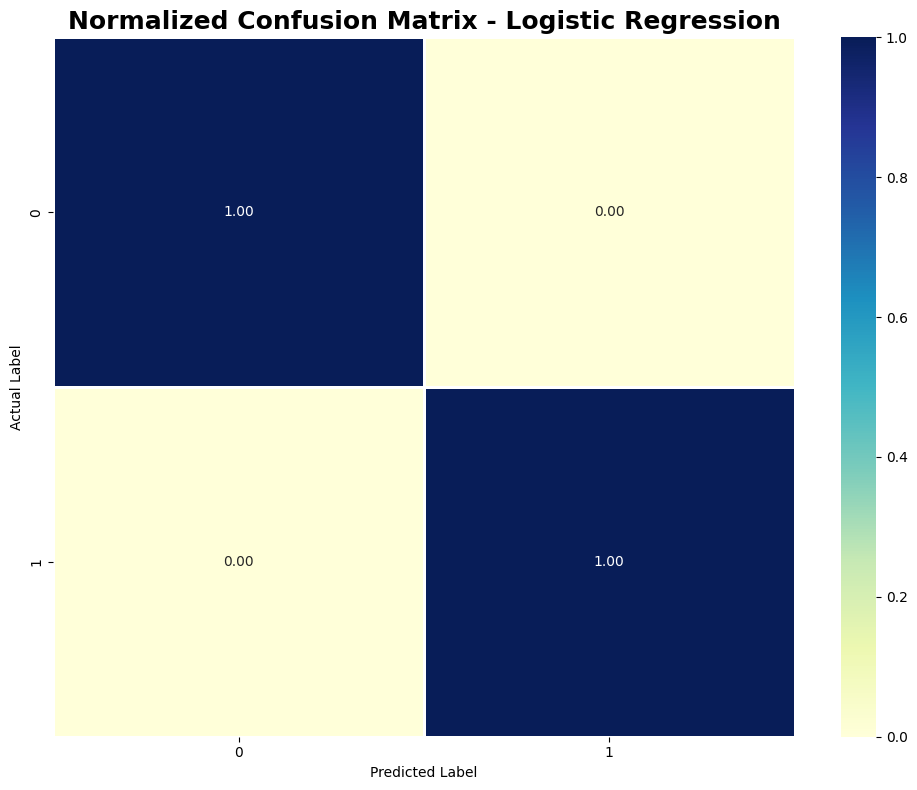



5-FOLD CROSS VALIDATION


,Model,CV Accuracy Mean (%),CV Accuracy Std (%)
0,Logistic Regression,100.00,0.01
2,Random Forest,100.00,0.01
6,AdaBoost,100.00,0.01
5,Hist Gradient Boosting,100.00,0.01
1,Decision Tree,99.99,0.01
4,Gradient Boosting,99.99,0.02
3,Extra Trees,99.98,0.04
9,SVM,99.88,0.07
7,KNN,99.20,0.14
8,Gaussian Naive Bayes,98.53,0.25


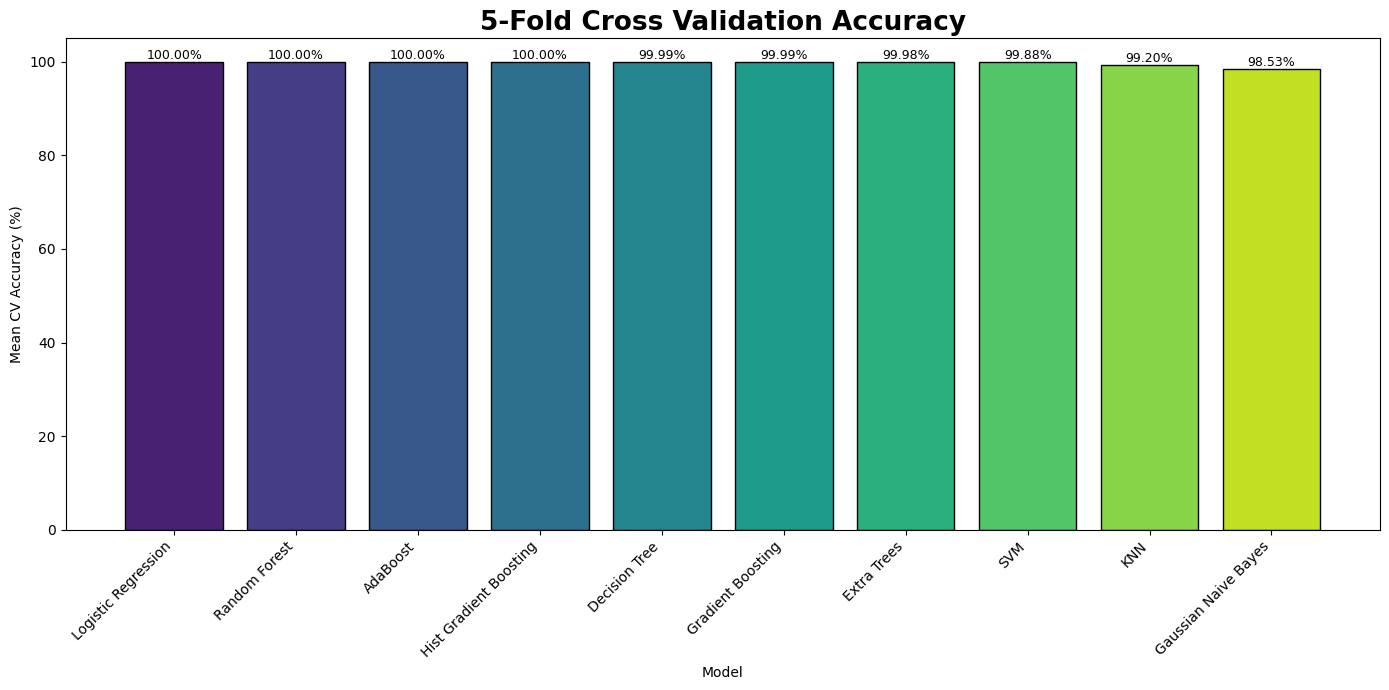



FINAL MACHINE LEARNING RESULT
Best Model      : Logistic Regression
Test Accuracy   : 100.00%
CV Accuracy     : 100.00%
CV Std          : 0.01%


In [14]:

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.pipeline import Pipeline

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


# ================================================================
# 2. COPY DATASET
# ================================================================

data = df.copy()

print("=" * 80)
print("ORIGINAL DATASET")
print("=" * 80)

print("Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())


# ================================================================
# 3. REMOVE DUPLICATES
# ================================================================

before = len(data)

data = data.drop_duplicates()

after = len(data)

print("\nDuplicates removed:", before - after)
print("New shape:", data.shape)


# ================================================================
# 4. TARGET VARIABLE
# ================================================================

TARGET = "sts_cd"

if TARGET not in data.columns:
    raise ValueError(
        f"Target column '{TARGET}' does not exist in the dataset."
    )

print("\nTarget column:", TARGET)

print("\nTarget distribution:")
print(data[TARGET].value_counts())


# ================================================================
# 5. REMOVE ROWS WHERE TARGET IS MISSING
# ================================================================

data = data.dropna(subset=[TARGET])

print("\nShape after removing missing target:")
print(data.shape)


# ================================================================
# 6. CONVERT DATE COLUMNS
# ================================================================

date_columns = [
    "apprvl_dt",
    "sign_dt"
]

for col in date_columns:

    if col in data.columns:

        data[col] = pd.to_datetime(
            data[col],
            errors="coerce"
        )


# ================================================================
# 7. CREATE DATE FEATURES
# ================================================================

for col in date_columns:

    if col in data.columns:

        data[f"{col}_year"] = data[col].dt.year
        data[f"{col}_month"] = data[col].dt.month
        data[f"{col}_quarter"] = data[col].dt.quarter
        data[f"{col}_dayofweek"] = data[col].dt.dayofweek


# ================================================================
# 8. PROJECT DURATION FEATURE
# ================================================================

if (
    "apprvl_dt" in data.columns
    and "sign_dt" in data.columns
):

    data["approval_to_sign_days"] = (
        data["sign_dt"] - data["apprvl_dt"]
    ).dt.days


# ================================================================
# 9. REMOVE ORIGINAL DATE COLUMNS
# ================================================================

data = data.drop(
    columns=[
        col for col in date_columns
        if col in data.columns
    ],
    errors="ignore"
)


# ================================================================
# 10. REMOVE ID / IDENTIFIER COLUMNS
# ================================================================

id_columns = [
    "oper_num"
]

data = data.drop(
    columns=[
        col for col in id_columns
        if col in data.columns
    ],
    errors="ignore"
)


# ================================================================
# 11. REMOVE OBJECTIVE TEXT COLUMN
# ================================================================

# objtv can contain long free-text descriptions.
# It is excluded from this standard ML pipeline.

if "objtv" in data.columns:

    data = data.drop(
        columns=["objtv"]
    )


# ================================================================
# 12. SEPARATE X AND Y
# ================================================================

X = data.drop(
    columns=[TARGET]
)

y = data[TARGET].copy()

print("\n")
print("=" * 80)
print("FEATURE / TARGET SHAPE")
print("=" * 80)

print("X Shape:", X.shape)
print("y Shape:", y.shape)


# ================================================================
# 13. LABEL ENCODE TARGET
# ================================================================

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    y.astype(str)
)

print("\nTarget Classes:")

for i, cls in enumerate(
    target_encoder.classes_
):
    print(i, "=", cls)


# ================================================================
# 14. IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ================================================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32", "bool"]
).columns.tolist()


print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# ================================================================
# 15. LABEL ENCODING FOR CATEGORICAL FEATURES
# ================================================================

X_encoded = X.copy()

label_encoders = {}

for col in categorical_features:

    le = LabelEncoder()

    # Convert missing values to string
    X_encoded[col] = X_encoded[col].fillna(
        "Missing"
    ).astype(str)

    X_encoded[col] = le.fit_transform(
        X_encoded[col]
    )

    label_encoders[col] = le


# ================================================================
# 16. CONVERT BOOLEAN COLUMNS
# ================================================================

for col in X_encoded.columns:

    if X_encoded[col].dtype == bool:

        X_encoded[col] = (
            X_encoded[col]
            .astype(int)
        )


# ================================================================
# 17. CONVERT EVERYTHING TO NUMERIC
# ================================================================

for col in X_encoded.columns:

    X_encoded[col] = pd.to_numeric(
        X_encoded[col],
        errors="coerce"
    )


# ================================================================
# 18. REPLACE INFINITE VALUES
# ================================================================

X_encoded = X_encoded.replace(
    [np.inf, -np.inf],
    np.nan
)


# ================================================================
# 19. HANDLE MISSING VALUES
# ================================================================

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(
    X_encoded
)

X_imputed = pd.DataFrame(
    X_imputed,
    columns=X_encoded.columns,
    index=X_encoded.index
)


# ================================================================
# 20. CHECK TARGET DISTRIBUTION
# ================================================================

print("\n")
print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

target_distribution = pd.Series(
    y_encoded
).value_counts().sort_index()

for class_id, count in target_distribution.items():

    class_name = target_encoder.inverse_transform(
        [class_id]
    )[0]

    percentage = (
        count / len(y_encoded)
    ) * 100

    print(
        f"{class_name}: "
        f"{count} samples "
        f"({percentage:.2f}%)"
    )


# ================================================================
# 21. TRAIN TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n")
print("=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print(
    "Training percentage:",
    round(
        len(X_train) / len(X_imputed) * 100,
        2
    ),
    "%"
)

print(
    "Testing percentage:",
    round(
        len(X_test) / len(X_imputed) * 100,
        2
    ),
    "%"
)


# ================================================================
# 22. FEATURE SCALING
# ================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ================================================================
# 23. DEFINE MACHINE LEARNING MODELS
# ================================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42,
            max_depth=15
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_depth=20
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_depth=20
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=150,
            learning_rate=0.05,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        ),

    "Gaussian Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        )
}


# ================================================================
# 24. TRAIN ALL MODELS
# ================================================================

results = []

trained_models = {}

predictions = {}

print("\n")
print("=" * 80)
print("MODEL TRAINING")
print("=" * 80)

for name, model in models.items():

    print(f"\nTraining: {name}")

    # Tree-based models can work without scaling,
    # but using scaled data gives a consistent pipeline.
    model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100
    })

    trained_models[name] = model

    predictions[name] = y_pred


# ================================================================
# 25. MODEL PERFORMANCE TABLE
# ================================================================

results_df = pd.DataFrame(
    results
).sort_values(
    by="Accuracy (%)",
    ascending=False
)

results_df = results_df.reset_index(
    drop=True
)

print("\n")
print("=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1 Score (%)": "{:.2f}"
    })
)


# ================================================================
# 26. ACCURACY COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

colors = sns.color_palette(
    "husl",
    len(results_df)
)

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Algorithm",
    fontsize=13
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(
    max(0, results_df["Accuracy (%)"].min() - 10),
    100
)

for bar, value in zip(
    bars,
    results_df["Accuracy (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ================================================================
# 27. PRECISION COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

precision_colors = sns.color_palette(
    "Set2",
    len(results_df)
)

bars = plt.bar(
    results_df["Model"],
    results_df["Precision (%)"],
    color=precision_colors,
    edgecolor="black"
)

plt.title(
    "Model Precision Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Precision (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    results_df["Precision (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 28. RECALL COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

recall_colors = sns.color_palette(
    "Spectral",
    len(results_df)
)

bars = plt.bar(
    results_df["Model"],
    results_df["Recall (%)"],
    color=recall_colors,
    edgecolor="black"
)

plt.title(
    "Model Recall Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Recall (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    results_df["Recall (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 29. F1 SCORE COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

f1_colors = sns.color_palette(
    "coolwarm",
    len(results_df)
)

bars = plt.bar(
    results_df["Model"],
    results_df["F1 Score (%)"],
    color=f1_colors,
    edgecolor="black"
)

plt.title(
    "Model F1 Score Comparison",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("F1 Score (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    results_df["F1 Score (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 30. BEST MODEL
# ================================================================

best_model_name = results_df.loc[
    0,
    "Model"
]

best_accuracy = results_df.loc[
    0,
    "Accuracy (%)"
]

best_model = trained_models[
    best_model_name
]

best_predictions = predictions[
    best_model_name
]

print("\n")
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print("Model:")
print(best_model_name)

print(
    f"Accuracy: {best_accuracy:.2f}%"
)


# ================================================================
# 31. CLASSIFICATION REPORT
# ================================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT - BEST MODEL")
print("=" * 80)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            str(x)
            for x in target_encoder.classes_
        ],
        zero_division=0
    )
)


# ================================================================
# 32. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    cbar=True
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()
plt.show()


# ================================================================
# 33. NORMALIZED CONFUSION MATRIX
# ================================================================

cm_normalized = (
    cm.astype(float)
    /
    cm.sum(
        axis=1,
        keepdims=True
    )
)

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=1,
    cbar=True
)

plt.title(
    f"Normalized Confusion Matrix - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.tight_layout()
plt.show()


# ================================================================
# 34. CROSS VALIDATION
# ================================================================

print("\n")
print("=" * 80)
print("5-FOLD CROSS VALIDATION")
print("=" * 80)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy Mean (%)":
            scores.mean() * 100,
        "CV Accuracy Std (%)":
            scores.std() * 100
    })

cv_df = pd.DataFrame(
    cv_results
).sort_values(
    by="CV Accuracy Mean (%)",
    ascending=False
)

display(
    cv_df.style.format({
        "CV Accuracy Mean (%)": "{:.2f}",
        "CV Accuracy Std (%)": "{:.2f}"
    })
)


# ================================================================
# 35. CROSS VALIDATION VISUALIZATION
# ================================================================

plt.figure(figsize=(14, 7))

cv_colors = sns.color_palette(
    "viridis",
    len(cv_df)
)

bars = plt.bar(
    cv_df["Model"],
    cv_df["CV Accuracy Mean (%)"],
    color=cv_colors,
    edgecolor="black"
)

plt.title(
    "5-Fold Cross Validation Accuracy",
    fontsize=19,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

for bar, value in zip(
    bars,
    cv_df["CV Accuracy Mean (%)"]
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ================================================================
# 36. FEATURE IMPORTANCE
# ================================================================

if hasattr(
    best_model,
    "feature_importances_"
):

    importance = pd.DataFrame({
        "Feature":
            X_train.columns,

        "Importance":
            best_model.feature_importances_
    })

    importance = (
        importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .head(20)
    )

    plt.figure(
        figsize=(12, 9)
    )

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="mako",
        legend=False
    )

    plt.title(
        f"Top 20 Feature Importances - {best_model_name}",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

    print("\nTop Important Features:")
    display(importance)


# ================================================================
# 37. FINAL RESULT
# ================================================================

print("\n")
print("=" * 80)
print("FINAL MACHINE LEARNING RESULT")
print("=" * 80)

print(
    f"Best Model      : {best_model_name}"
)

print(
    f"Test Accuracy   : {best_accuracy:.2f}%"
)

best_cv = cv_df.iloc[0]

print(
    f"CV Accuracy     : "
    f"{best_cv['CV Accuracy Mean (%)']:.2f}%"
)

print(
    f"CV Std          : "
    f"{best_cv['CV Accuracy Std (%)']:.2f}%"
)

print("=" * 80)

## Thank you..pls upvote!!!!!!!!!!!